In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import importlib
import pickle
import aux_functions as aux
importlib.reload(aux)

<module 'aux_functions' from 'e:\\vispred\\aux_functions.py'>

In [ ]:
with open(f"pkl_aux_data\\df_locs_idx.pkl", "rb") as file:
    df_locs_geral= pickle.load(file)

def vector_sacc(idx_start, idx_end):
    loc_start = np.array(df_locs_geral[df_locs_geral['Idx']==idx_start].iloc[0][['X_','Y_']],dtype=int)
    loc_end = np.array(df_locs_geral[df_locs_geral['Idx']==idx_end].iloc[0][['X_','Y_']],dtype=int)
    return loc_end-loc_start

def idx_vector_sacc(idx_start, idx_end):
    try:
        return df_locs_geral[df_locs_geral['LOC']==tuple(vector_sacc(idx_start, idx_end))].iloc[0]['Idx']
    except IndexError:
        return np.nan

dicio_sacc_vectors = {}
for idx_start in range(21):
    for idx_end in range(21):
        dicio_sacc_vectors[(idx_start,idx_end)] = idx_vector_sacc(idx_start, idx_end)

with open(f"pkl_aux_data\\dicio_sacc_vectors.pkl", "wb") as file:
    pickle.dump(dicio_sacc_vectors, file)


# with open(f"pkl_aux_data\\dicio_sacc_vectors.pkl", "rb") as file:
    # dicio_sacc_vectors= pickle.load(file)

In [2]:
MONKEY = 'M08'
# SESSION = 'm08cat156'
SESSION = 'm08cat255'
STR_DETAILS = f'Session {SESSION}'

In [3]:
with open(f"session_data/{SESSION}.pkl", "rb") as file:
    df_session= pickle.load(file)
df_session

,start,search,mapRF,grid_coord,depth,brain_area,sample,array,prefer,SI,RFin,RFout,RF_type,session,neuron_id,coreRFin,
0,847,m08cat255spk033a,m08det254spk033a,-1+5,1186,TE,0.0,NaN,face,0.38549,NaN,NaN,Focal Foveal,m08cat255,spk033a,NaN,NaN
1,848,m08cat255spk033z,m08det254spk033z,-1+5,1186,TE,0.0,NaN,face,0.51208,NaN,NaN,Focal Foveal,m08cat255,spk033z,NaN,NaN
2,849,m08cat255spk034a,m08det254spk034a,-1+5,1346,TE,0.0,NaN,face,0.60449,NaN,NaN,Focal Foveal,m08cat255,spk034a,NaN,NaN
3,850,m08cat255spk034b,m08det254spk034b,-1+5,1346,TE,0.0,NaN,face,1.00000,NaN,NaN,Focal Foveal,m08cat255,spk034b,NaN,NaN
4,851,m08cat255spk034c,m08det254spk034c,-1+5,1346,TE,0.0,0.0,face,0.56654,"0,8,19","1,2,3,4,5,6,7,9,10,11,12,13,14,15,16,17,18,20",Broad Foveal,m08cat255,spk034c,"0,8,19",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
226,1140,m08cat255spk091b,m08det254spk091b,B+4-4,720,VPA,0.0,0.0,NaN,0.13946,NaN,NaN,Broad Foveal,m08cat255,spk091b,NaN,NaN
227,1141,m08cat255spk091z,m08det254spk091z,B+4-4,720,VPA,NaN,0.0,NaN,NaN,NaN,NaN,Peripheral,m08cat255,spk091z,NaN,NaN
228,1142,m08cat255spk093b,m08det254spk093b,B+4-4,735,VPA,0.0,0.0,NaN,-0.36007,NaN,NaN,Broad Foveal,m08cat255,spk093b,NaN,NaN
229,1143,m08cat255spk095a,m08det254spk095a,B+4-4,750,VPA,NaN,0.0,NaN,NaN,NaN,NaN,Peripheral,m08cat255,spk095a,NaN,NaN


In [4]:
df_session = df_session[(df_session['RF_type']=='Focal Foveal') | ~(df_session['RFin'].isna())]

In [5]:
df_session['RF_type'].unique()

array(['Focal Foveal', 'Broad Foveal'], dtype=object)

In [6]:
df_session[df_session['RF_type']=='Peripheral']

,start,search,mapRF,grid_coord,depth,brain_area,sample,array,prefer,SI,RFin,RFout,RF_type,session,neuron_id,coreRFin,
88,546,m08cat156spk097a,m08det155spk097a,+1-5,690,V4,NaN,0.0,NaN,0.096865,"5,6,15","0,9,1,2,3,4,7,8,10,11,12,13,14,16,17,18,19,20",Peripheral,m08cat156,spk097a,NaN,NaN
89,547,m08cat156spk097z,m08det155spk097z,+1-5,690,V4,NaN,0.0,NaN,0.161360,"5,6","0,1,2,3,4,7,8,9,10,11,12,13,14,15,16,17,18,19,20",Peripheral,m08cat156,spk097z,NaN,NaN
93,551,m08cat156spk099a,m08det155spk099a,+1-5,710,V4,NaN,0.0,NaN,0.071550,"5,6","0,10,1,2,3,4,7,8,9,11,12,13,14,15,16,17,18,19,20",Peripheral,m08cat156,spk099a,NaN,NaN
94,552,m08cat156spk099z,m08det155spk099z,+1-5,710,V4,NaN,0.0,NaN,0.235220,"6,5","0,1,2,3,4,7,8,9,10,11,12,13,14,15,16,17,18,19,20",Peripheral,m08cat156,spk099z,NaN,NaN
98,556,m08cat156spk101a,m08det155spk101a,+1-5,730,V4,NaN,0.0,NaN,0.123180,"5,6","0,1,2,3,4,7,8,9,10,11,12,13,14,15,16,17,18,19,20",Peripheral,m08cat156,spk101a,NaN,NaN
105,563,m08cat156spk103a,m08det155spk103a,+1-5,750,V4,NaN,0.0,NaN,0.415990,"5,6","0,18,1,2,3,4,7,8,9,10,11,12,13,14,15,16,17,19,20",Peripheral,m08cat156,spk103a,NaN,NaN
111,569,m08cat156spk105a,m08det155spk105a,+1-5,770,V4,NaN,0.0,NaN,0.014790,"5,6","0,1,2,3,4,7,8,9,10,11,12,13,14,15,16,17,18,19,20",Peripheral,m08cat156,spk105a,NaN,NaN


In [7]:
df_session[df_session['RF_type']=='Broad Foveal']

,start,search,mapRF,grid_coord,depth,brain_area,sample,array,prefer,SI,RFin,RFout,RF_type,session,neuron_id,coreRFin,
18,1807,m08cat156spk034a,m08det155spk034a,+1+3,1686,TEO,0.0,0.0,NaN,0.004952,"0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18...",,Broad Foveal,m08cat156,spk034a,"0,2,4,5,6,12,15",NaN
19,1808,m08cat156spk034b,m08det155spk034b,+1+3,1686,TEO,0.0,0.0,NaN,-0.002620,"0,4,5,6,13,14","1,2,3,7,8,9,10,11,12,15,16,17,18,19,20",Broad Foveal,m08cat156,spk034b,"0,4,5,6,13",NaN
20,1809,m08cat156spk034c,m08det155spk034c,+1+3,1686,TEO,0.0,0.0,NaN,0.030485,"0,2,3,4,5,6,13,14","1,7,8,9,10,11,12,15,16,17,18,19,20",Broad Foveal,m08cat156,spk034c,"0,4",NaN
23,1812,m08cat156spk036a,m08det155spk036a,+1+3,1696,TEO,0.0,0.0,NaN,0.011836,"0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18...",,Broad Foveal,m08cat156,spk036a,"0,2,4,5,6,14,16",NaN
24,1813,m08cat156spk036b,m08det155spk036b,+1+3,1696,TEO,0.0,0.0,NaN,0.050764,"0,2,4,6","1,3,5,7,8,9,10,11,12,13,14,15,16,17,18,19,20",Broad Foveal,m08cat156,spk036b,"0,2,6",NaN
25,1814,m08cat156spk036c,m08det155spk036c,+1+3,1696,TEO,0.0,0.0,NaN,-0.065521,"0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18...",,Broad Foveal,m08cat156,spk036c,"0,2,3,4,5,6",NaN
26,1815,m08cat156spk036z,m08det155spk036z,+1+3,1696,TEO,0.0,0.0,NaN,-0.014624,"0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18...",,Broad Foveal,m08cat156,spk036z,"0,1,4,5,6,9,12,13,14,15,18",NaN
27,1817,m08cat156spk038a,m08det155spk038a,+1+3,1706,TEO,0.0,0.0,NaN,0.029749,"0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18...",,Broad Foveal,m08cat156,spk038a,"0,4,5,6",NaN
38,1828,m08cat156spk043b,m08det155spk043b,+1+3,1576,TEO,0.0,0.0,house,-0.315920,"0,3,4,5,6,12,13,14,15,16,17","1,2,7,8,9,10,11,18,19,20",Broad Foveal,m08cat156,spk043b,"0,3,4,5,6,12,13,16,17",NaN
43,1833,m08cat156spk045a,m08det155spk045a,+1+3,1586,TEO,0.0,0.0,house,-0.221140,"0,1,2,3,4,5,6,12,13,14,16","7,8,9,10,11,15,17,18,19,20",Broad Foveal,m08cat156,spk045a,"0,1,3,4,5,6,12,13,14,16",NaN


In [ ]:
# path_destiny = f'dados/{MONKEY}_neurons/neurons sorted' # linux
# list_neuron_ids = df_session['search']
# list_prefered_cat = df_session['prefer']
# list_brain_area = df_session['brain_area']
# list_RF_type = df_session['RF_type']

# df_trials = aux.get_df_trials(list_neuron_ids, path_destiny, list(list_prefered_cat), list(list_brain_area), list(list_RF_type), firings_cue_and_array=True)
# df_trials



In [ ]:
# with open(f"pkl_aux_data\\df_locs_idx.pkl", "wb") as file:
    # pickle.dump(df_locs_geral, file)

In [6]:
with open(f"pkl_aux_data\\df_locs_idx.pkl", "rb") as file:
    df_locs_geral= pickle.load(file)

def vector_sacc(idx_start, idx_end):
    loc_start = np.array(df_locs_geral[df_locs_geral['Idx']==idx_start].iloc[0][['X_','Y_']],dtype=int)
    loc_end = np.array(df_locs_geral[df_locs_geral['Idx']==idx_end].iloc[0][['X_','Y_']],dtype=int)
    return loc_end-loc_start

def idx_vector_sacc(idx_start, idx_end):
    try:
        return df_locs_geral[df_locs_geral['LOC']==tuple(vector_sacc(idx_start, idx_end))].iloc[0]['Idx']
    except IndexError:
        return np.nan

In [7]:
dicio_sacc_vectors = {}
for idx_start in range(21):
    for idx_end in range(21):
        dicio_sacc_vectors[(idx_start,idx_end)] = idx_vector_sacc(idx_start, idx_end)

dicio_sacc_vectors

{(0, 0): 0.0,
 (0, 1): 1.0,
 (0, 2): 2.0,
 (0, 3): 3.0,
 (0, 4): 4.0,
 (0, 5): 5.0,
 (0, 6): 6.0,
 (0, 7): 7.0,
 (0, 8): 8.0,
 (0, 9): 9.0,
 (0, 10): 10.0,
 (0, 11): 11.0,
 (0, 12): 12.0,
 (0, 13): 13.0,
 (0, 14): 14.0,
 (0, 15): 15.0,
 (0, 16): 16.0,
 (0, 17): 17.0,
 (0, 18): 18.0,
 (0, 19): 19.0,
 (0, 20): 20.0,
 (1, 0): 5.0,
 (1, 1): 0.0,
 (1, 2): 4.0,
 (1, 3): 13.0,
 (1, 4): 14.0,
 (1, 5): nan,
 (1, 6): 15.0,
 (1, 7): 16.0,
 (1, 8): 6.0,
 (1, 9): 2.0,
 (1, 10): 3.0,
 (1, 11): 12.0,
 (1, 12): nan,
 (1, 13): nan,
 (1, 14): nan,
 (1, 15): nan,
 (1, 16): nan,
 (1, 17): nan,
 (1, 18): 17.0,
 (1, 19): 7.0,
 (1, 20): 8.0,
 (2, 0): 6.0,
 (2, 1): 8.0,
 (2, 2): 0.0,
 (2, 3): 4.0,
 (2, 4): 5.0,
 (2, 5): 15.0,
 (2, 6): 16.0,
 (2, 7): 17.0,
 (2, 8): 7.0,
 (2, 9): 1.0,
 (2, 10): 2.0,
 (2, 11): 3.0,
 (2, 12): 13.0,
 (2, 13): 14.0,
 (2, 14): nan,
 (2, 15): nan,
 (2, 16): nan,
 (2, 17): nan,
 (2, 18): nan,
 (2, 19): 18.0,
 (2, 20): 19.0,
 (3, 0): 7.0,
 (3, 1): 19.0,
 (3, 2): 8.0,
 (3, 3): 0.0,
 (3,

## (criar df locs)

In [9]:
import scipy.io as sio

In [10]:
neuron_id = list_neuron_ids[0]
trial_path = f'{path_destiny}/{neuron_id}.mat'
mat_data = sio.loadmat(trial_path)

In [39]:
len(mat_data['SearchEye'])

2786

In [66]:
mat_data['SearchEye'][10][0][2][3:6]

array([3., 0., 7.])

In [46]:
# for trial_idx, trial_data in enumerate(mat_data['TrlInfoMatrix']):
    # if mat_data['SearchEye'][trial_idx][0].shape[1] != 8:
        # continue
    # else:
        # trial_num = int(trial_data[0])

df_locs = []
for trial_idx, trial_data in enumerate(mat_data['TrlInfoMatrix']):
    if mat_data['SearchEye'][trial_idx][0].shape[1] != 8:
        continue
    else:
        for sacc_idx in range(len(mat_data['SearchEye'][trial_idx][0])):
            [sti_loc_idx, sti_loc_x, sti_loc_y] = mat_data['SearchEye'][trial_idx][0][sacc_idx][3:6]
            df_locs.append([sti_loc_idx, sti_loc_x, sti_loc_y])


In [176]:
mat_data['TrlInfoMatrix'][1][23]

6.112666666666667

In [178]:
mat_data['SearchEye'][1][0][1]#[6]

array([   2.        ,    6.1306    ,    6.24566667,   19.        ,
          7.        ,   -7.        , 1017.        ,    4.        ])

In [47]:
df_locs = pd.DataFrame(df_locs, columns = ['Idx','X','Y'])

In [59]:
df_locs_geral = df_locs.drop_duplicates().sort_values('Idx')

In [61]:
df_locs_geral.index = range(len(df_locs_geral.index))
df_locs_geral

,Idx,X,Y
0,0.0,0.0,0.0
1,1.0,7.0,0.0
2,2.0,4.0,4.0
3,3.0,0.0,7.0
4,4.0,-4.0,4.0
5,5.0,-7.0,0.0
6,6.0,-4.0,-4.0
7,7.0,0.0,-7.0
8,8.0,4.0,-4.0
9,9.0,11.0,4.0


In [83]:
def prod_int(x,y):
    return x[0]*y[0]+x[1]*y[1]
def norm(x): return np.sqrt(prod_int(x,x))
def dist(x,y):
    return norm(x-y)

In [92]:
def transform_loc(loc):
    return {
        0.0:0,
        4.0:1,
        -4.0:-1,
        7.0:2,
        -7.0:-2,
        11.0:3,
        -11.0:-3
    }[loc]

df_locs_geral['X_'] = df_locs_geral['X'].apply(transform_loc)
df_locs_geral['Y_'] = df_locs_geral['Y'].apply(transform_loc)
df_locs_geral

,Idx,X,Y,X_,Y_
0,0.0,0.0,0.0,0,0
1,1.0,7.0,0.0,2,0
2,2.0,4.0,4.0,1,1
3,3.0,0.0,7.0,0,2
4,4.0,-4.0,4.0,-1,1
5,5.0,-7.0,0.0,-2,0
6,6.0,-4.0,-4.0,-1,-1
7,7.0,0.0,-7.0,0,-2
8,8.0,4.0,-4.0,1,-1
9,9.0,11.0,4.0,3,1


In [96]:
# df_locs_geral['LOC'] =
df_LOC = {}
for idx,row in df_locs_geral.iterrows():
    df_LOC[idx] = (row['X_'],row['Y_'])
df_locs_geral['LOC'] = pd.Series(df_LOC,dtype=int)
df_locs_geral

,Idx,X,Y,X_,Y_,LOC
0,0.0,0.0,0.0,0,0,"(0, 0)"
1,1.0,7.0,0.0,2,0,"(2, 0)"
2,2.0,4.0,4.0,1,1,"(1, 1)"
3,3.0,0.0,7.0,0,2,"(0, 2)"
4,4.0,-4.0,4.0,-1,1,"(-1, 1)"
5,5.0,-7.0,0.0,-2,0,"(-2, 0)"
6,6.0,-4.0,-4.0,-1,-1,"(-1, -1)"
7,7.0,0.0,-7.0,0,-2,"(0, -2)"
8,8.0,4.0,-4.0,1,-1,"(1, -1)"
9,9.0,11.0,4.0,3,1,"(3, 1)"


In [103]:
df_locs_geral['LOC']

0       (0, 0)
1       (2, 0)
2       (1, 1)
3       (0, 2)
4      (-1, 1)
5      (-2, 0)
6     (-1, -1)
7      (0, -2)
8      (1, -1)
9       (3, 1)
10      (2, 2)
11      (1, 3)
12     (-1, 3)
13     (-2, 2)
14     (-3, 1)
15    (-3, -1)
16    (-2, -2)
17    (-1, -3)
18     (1, -3)
19     (2, -2)
20     (3, -1)
Name: LOC, dtype: object

In [101]:
df_locs_geral[df_locs_geral['LOC']==tuple(np.array([3,-1]) - np.array([2,2]))].index[0]

18

In [137]:
idx_vector_sacc(17,19)
# idx_vector_sacc(20,12)

9.0

In [126]:
df_locs_geral[df_locs_geral['LOC']==tuple(vector_sacc(2,9))].iloc[0]['Idx']#1 
df_locs_geral[df_locs_geral['LOC']==tuple(vector_sacc(3,10))].iloc[0]['Idx']#1 
df_locs_geral[df_locs_geral['LOC']==tuple(vector_sacc(13,3))].iloc[0]['Idx']#1

df_locs_geral[df_locs_geral['LOC']==tuple(vector_sacc(1,2))].iloc[0]['Idx']#4
df_locs_geral[df_locs_geral['LOC']==tuple(vector_sacc(3,12))].iloc[0]['Idx']#4
df_locs_geral[df_locs_geral['LOC']==tuple(vector_sacc(7,6))].iloc[0]['Idx']#4


4.0

In [116]:
np.array(df_locs_geral[df_locs_geral['Idx']==10].iloc[0][['X_','Y_']],dtype=int)

array([2, 2])

In [91]:
# print(dist(np.array([0,0]),np.array([3.5,3.5])))
# print(dist(np.array([0,0]),np.array([4,4])))
# print(dist(np.array([3.5,3.5]),np.array([0,7])))
# print(dist(np.array([4,4]),np.array([0,7])))
# 
# print(dist(np.array([4,11]),np.array([0,7])))
# print(dist(np.array([3.5,10.5]),np.array([0,7])))
# 

4.949747468305833
5.656854249492381
4.949747468305833
5.0
5.656854249492381
4.949747468305833


(array([-3.5,  3.5]), array([ 3.5, -3.5]), 24.5, 24.5)

In [102]:
with open(f"pkl_aux_data\\df_locs_idx.pkl", "wb") as file:
    pickle.dump(df_locs_geral, file)

In [49]:
df_locs[df_locs['Idx']==19]

,Idx,X,Y
1,19.0,7.0,-7.0
46,19.0,7.0,-7.0
61,19.0,7.0,-7.0
86,19.0,7.0,-7.0
94,19.0,7.0,-7.0
...,...,...,...
5034,19.0,7.0,-7.0
5038,19.0,7.0,-7.0
5100,19.0,7.0,-7.0
5146,19.0,7.0,-7.0


## df trials com todas as sacadas (não só a primeira)

In [ ]:
import traceback
import scipy.io as sio
from aux_functions import get_image_cathegory

def get_df_trials_all_saccs(list_neuron_ids, path_destiny, list_prefered_cat, list_brain_area, list_RF_type, list_RF_IN):
    trial_num_TrialInfoIdx = 0 # Numero da trial
    trial_cue_imgid_TrialInfoIdx = 4 # Id da foto da pista
    trial_FP_on_time_TrialInfoIdx =  17 # Fixation point na tela
    trial_fix_FP_TrialInfoIdx =  18 # Macaco fixa o FP
    trial_cue_on_time_TrialInfoIdx = 19 # pista aparece
    trial_cue_off_time_TrialInfoIdx = 20 # pista desaparece
    trial_FP_back_time_TrialInfoIdx =  21 # Fixation point reaparece
    trial_array_on_time_TrialInfoIdx = 22 # array aparece
    trial_1sacc_time_TrialInfoIdx = 23 # tempo do inicio da primeira sacada
    rows_df = []
    dicio_firings = {}
    for i, neuron_id in enumerate(list_neuron_ids):
        trial_path = f'{path_destiny}/{neuron_id}.mat' 
        try:
            mat_data = sio.loadmat(trial_path)
            prefered_cat = list_prefered_cat[i]
            brain_area = list_brain_area[i]
            RF_type = list_RF_type[i]
            RF_in = list_RF_IN[i]
            if pd.isnull(RF_in):
                ROWS_RF_IN = [False]* 21
            else:
                RF_in_list = RF_in.split(',')
                ROWS_RF_IN = [str(index_rf) in RF_in_list for index_rf in range(21)]
            dicio_firings[neuron_id] = mat_data['neuron']
            for trial_idx, trial_data in enumerate(mat_data['TrlInfoMatrix']):
                if mat_data['SearchEye'][trial_idx][0].shape[1] != 8: # trial problematica
                    continue
                trial_1sacc_time = trial_data[trial_1sacc_time_TrialInfoIdx]
                if pd.isnull(trial_1sacc_time): continue
                trial_num = int(trial_data[trial_num_TrialInfoIdx])
                trial_cue_imgid = trial_data[trial_cue_imgid_TrialInfoIdx]
                trial_FP_on_time = trial_data[trial_FP_on_time_TrialInfoIdx]
                trial_fix_FP = trial_data[trial_fix_FP_TrialInfoIdx]
                trial_cue_on_time = trial_data[trial_cue_on_time_TrialInfoIdx]
                trial_cue_off_time = trial_data[trial_cue_off_time_TrialInfoIdx]
                trial_FP_back_time = trial_data[trial_FP_back_time_TrialInfoIdx]
                trial_array_on_time = trial_data[trial_array_on_time_TrialInfoIdx]
                cue_category = get_image_cathegory(trial_cue_imgid)
                trial_presacc_time = trial_1sacc_time - trial_array_on_time
                OFF_TIME_ANTERIOR = trial_1sacc_time
                LOC_ANTERIOR = 0
                CAT_ANTERIOR = 'FP'
                for sacc_idx, sacc_data in enumerate(mat_data['SearchEye'][trial_idx][0][1:]): # 0 pq tudo ta num grande array, 1+ pq 0 é a fixação no FP
                    sti_loc_idx = sacc_data[3] # id da localização no array (0-20)
                    image_id = sacc_data[6] # id da imagem
                    image_cat = get_image_cathegory(image_id)
                    target_on_time = sacc_data[1] # tempo de quando esse objeto foi fixado
                    target_off_time = sacc_data[2] # tempo de fim da sacada
                    SACC_VECTOR = dicio_sacc_vectors[(LOC_ANTERIOR, sti_loc_idx)]
                    VECTOR_IN_RF = False
                    if not pd.isnull(SACC_VECTOR):
                        try:
                            VECTOR_IN_RF = ROWS_RF_IN[int(SACC_VECTOR)]
                        except Exception as e:
                            print('=====')
                            print(traceback.format_exc())
                            print('---')
                            print('rows rf in=',ROWS_RF_IN)
                            print('---')
                            print('sacc vector=',SACC_VECTOR)
                            print('---')
                            print(int(SACC_VECTOR))
                            print('---')
                            raise e
                    rows_df.append([
                        neuron_id,
                        prefered_cat,
                        brain_area,
                        RF_type,
                        RF_in,
                        trial_num,
                        trial_cue_imgid,
                        cue_category,
                        trial_presacc_time,
                        trial_FP_on_time,
                        trial_fix_FP,
                        trial_cue_on_time,
                        trial_cue_off_time,
                        trial_FP_back_time,
                        trial_array_on_time,
                        trial_1sacc_time,
                        sacc_idx,
                        f'{trial_num}_{sacc_idx}',
                        sti_loc_idx,
                        image_id,
                        image_cat,
                        OFF_TIME_ANTERIOR,
                        target_on_time,
                        target_off_time,
                        LOC_ANTERIOR,
                        CAT_ANTERIOR,
                        SACC_VECTOR,
                        VECTOR_IN_RF,
                        ])
                    OFF_TIME_ANTERIOR = target_off_time # depois de guardar a row, atualiza o tempo de Saída da sacada para o próximo
                    LOC_ANTERIOR = sti_loc_idx
                    CAT_ANTERIOR = image_cat

        except Exception as e:
            print('ERRO!!!', neuron_id) 
            print(traceback.format_exc())
            raise e

    df_trials = pd.DataFrame(rows_df, columns=[
        'neuron',
        'prefered',
        'brain_area',
        'RF_type',
        'RF_in',
        'trial_num',
        'cue_id',
        'cue_cath',
        'pre_sacc_time',
        'FP_on',
        'fix_FP',
        'cue_on',
        'cue_off',
        'FP_back',
        'array_on',
        '1sacc_start',
        'sacc_num',
        'trial+sacc',
        'sacc_stim_loc',
        'sacc_img_id',
        'sacc_img_cath',
        'sacc_start_time',
        'fix_time',
        'fix_end_time',
        'stim_loc_anterior',
        'img_cath_anterior',
        'saccade_vector',
        'vector_in_RF'
        ])
    return df_trials, dicio_firings


In [9]:
path_destiny = f'dados/{MONKEY}_neurons/neurons sorted' # linux
list_neuron_ids = df_session['search']
list_prefered_cat = df_session['prefer']
list_brain_area = df_session['brain_area']
list_RF_type = df_session['RF_type']
list_RF_in = df_session['RFin']

df_trials, dicio_firings = get_df_trials_all_saccs(list_neuron_ids, path_destiny, list(list_prefered_cat), list(list_brain_area), list(list_RF_type), list(list_RF_in))
df_trials

,neuron,prefered,brain_area,RF_type,RF_in,trial_num,cue_id,cue_cath,pre_sacc_time,FP_on,...,sacc_stim_loc,sacc_img_id,sacc_img_cath,sacc_start_time,fix_time,fix_end_time,stim_loc_anterior,img_cath_anterior,saccade_vector,vector_in_RF
0,m08cat255spk033a,face,TE,Focal Foveal,NaN,3,1020.0,flower,0.137433,5.065133,...,4.0,2030.0,house,6.931400,6.947333,7.057100,0.0,FP,4.0,False
1,m08cat255spk033a,face,TE,Focal Foveal,NaN,3,1020.0,flower,0.137433,5.065133,...,12.0,3029.0,face,7.057100,7.062267,7.065067,4.0,house,3.0,False
2,m08cat255spk033a,face,TE,Focal Foveal,NaN,3,1020.0,flower,0.137433,5.065133,...,11.0,1020.0,flower,7.065067,7.078200,7.884033,12.0,face,1.0,False
3,m08cat255spk033a,face,TE,Focal Foveal,NaN,4,3022.0,face,0.155533,8.988067,...,7.0,3022.0,face,10.830700,10.832767,11.640533,0.0,FP,7.0,False
4,m08cat255spk033a,face,TE,Focal Foveal,NaN,5,2020.0,house,0.165867,12.695667,...,4.0,3005.0,face,14.604200,14.607900,14.794833,0.0,FP,4.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
947515,m08cat255spk083b,NaN,VPA,Focal Foveal,NaN,2669,3003.0,face,0.156400,12854.442967,...,4.0,2027.0,house,12859.105500,12859.107533,12859.298400,0.0,FP,4.0,False
947516,m08cat255spk083b,NaN,VPA,Focal Foveal,NaN,2669,3003.0,face,0.156400,12854.442967,...,5.0,3028.0,face,12859.298400,12859.300467,12859.461000,4.0,house,6.0,False
947517,m08cat255spk083b,NaN,VPA,Focal Foveal,NaN,2669,3003.0,face,0.156400,12854.442967,...,6.0,1022.0,flower,12859.461000,12859.463067,12859.467000,5.0,face,8.0,False
947518,m08cat255spk083b,NaN,VPA,Focal Foveal,NaN,2669,3003.0,face,0.156400,12854.442967,...,19.0,2012.0,house,12859.467000,12859.474833,12859.766900,6.0,flower,20.0,False


In [12]:
df_trials[(df_trials['vector_in_RF']==True) & (df_trials['RF_type']=='Peripheral')]

,neuron,prefered,brain_area,RF_type,RF_in,trial_num,cue_id,cue_cath,pre_sacc_time,FP_on,...,sacc_stim_loc,sacc_img_id,sacc_img_cath,sacc_start_time,fix_time,fix_end_time,stim_loc_anterior,img_cath_anterior,saccade_vector,vector_in_RF
196151,m08cat156spk097a,NaN,V4,Peripheral,"5,6,15",2,3014.0,face,0.146367,4.168067,...,18.0,1040.0,flower,6.245667,6.248400,6.251233,19.0,flower,6.0,True
196152,m08cat156spk097a,NaN,V4,Peripheral,"5,6,15",2,3014.0,face,0.146367,4.168067,...,17.0,3027.0,face,6.251233,6.254700,7.063400,18.0,flower,5.0,True
196154,m08cat156spk097a,NaN,V4,Peripheral,"5,6,15",3,3013.0,face,0.135033,8.021567,...,7.0,2015.0,house,10.682500,10.684533,10.824300,8.0,flower,6.0,True
196155,m08cat156spk097a,NaN,V4,Peripheral,"5,6,15",3,3013.0,face,0.135033,8.021567,...,16.0,2032.0,house,10.824300,10.826367,11.004333,7.0,house,5.0,True
196164,m08cat156spk097a,NaN,V4,Peripheral,"5,6,15",6,3029.0,face,0.152500,21.019133,...,14.0,3002.0,face,23.798333,23.800333,24.608800,4.0,house,5.0,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
227515,m08cat156spk105a,NaN,V4,Peripheral,"5,6",2764,3007.0,face,0.145200,12430.372800,...,7.0,1008.0,flower,12434.159967,12434.162000,12434.314567,8.0,house,6.0,True
227520,m08cat156spk105a,NaN,V4,Peripheral,"5,6",2766,2057.0,house,0.149200,12438.940633,...,6.0,2057.0,house,12441.970167,12441.972233,12442.138367,8.0,face,5.0,True
227521,m08cat156spk105a,NaN,V4,Peripheral,"5,6",2766,2057.0,house,0.149200,12438.940633,...,15.0,3023.0,face,12442.138367,12442.140400,12442.324300,6.0,house,5.0,True
227524,m08cat156spk105a,NaN,V4,Peripheral,"5,6",2766,2057.0,house,0.149200,12438.940633,...,14.0,4027.0,hand,12442.631900,12442.634000,12443.022267,13.0,hand,6.0,True


In [13]:
df_trials.columns

Index(['neuron', 'prefered', 'brain_area', 'RF_type', 'RF_in', 'trial_num',
       'cue_id', 'cue_cath', 'pre_sacc_time', 'FP_on', 'fix_FP', 'cue_on',
       'cue_off', 'FP_back', 'array_on', '1sacc_start', 'sacc_num',
       'trial+sacc', 'sacc_stim_loc', 'sacc_img_id', 'sacc_img_cath',
       'sacc_start_time', 'fix_time', 'fix_end_time', 'stim_loc_anterior',
       'img_cath_anterior', 'saccade_vector', 'vector_in_RF'],
      dtype='object')

In [11]:
dicio_firings['m08cat156spk002a']

array([[1.44333333e-02, 1.20800000e-01, 1.27133333e-01, ...,
        1.25412362e+04, 1.25412391e+04, 1.25412561e+04]])

# análise teste

In [14]:
duracao_sacada = df_trials['fix_time'] - df_trials['sacc_start_time']
duracao_fix = df_trials['fix_end_time'] - df_trials['fix_time']

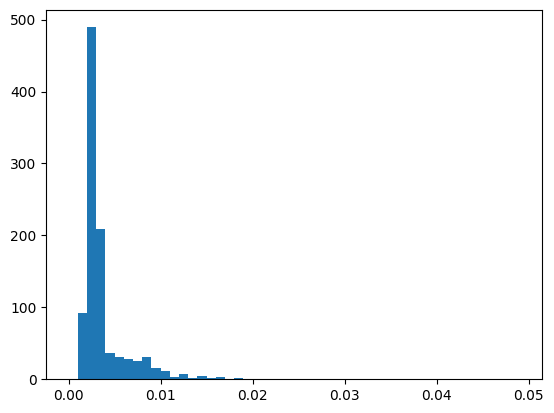

In [15]:
plt.hist(duracao_sacada, bins=np.arange(0,0.05,0.001),cumulative=False,density=True)
plt.show()

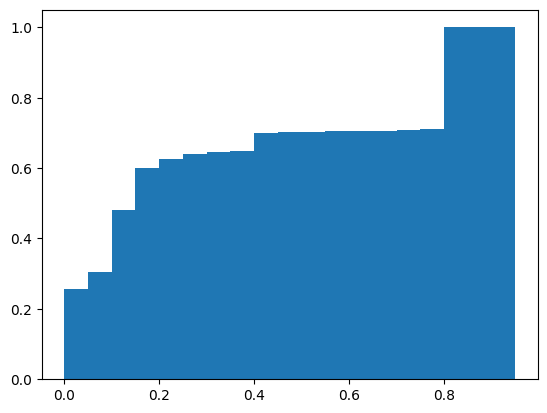

In [16]:
plt.hist(duracao_fix, bins=np.arange(0,1,0.05),cumulative=True,density=True)
plt.show()

In [17]:
df_session[df_session['RF_type']=='Peripheral']

,start,search,mapRF,grid_coord,depth,brain_area,sample,array,prefer,SI,RFin,RFout,RF_type,session,neuron_id,coreRFin,


In [44]:
neurons_periph = list(df_session[df_session['RF_type']=='Peripheral']['search'])
df_trials[df_trials['neuron'].isin(neurons_periph) & df_trials['saccade_vector'].isin([5.0,6.0])].sort_values('trial_num')


,neuron,prefered,brain_area,RF_type,RF_in,trial_num,cue_id,cue_cath,pre_sacc_time,FP_on,...,sacc_num,sacc_stim_loc,sacc_img_id,sacc_img_cath,sacc_start_time,fix_time,fix_end_time,stim_loc_anterior,img_cath_anterior,saccade_vector
196151,m08cat156spk097a,NaN,V4,Peripheral,"5,6,15",2,3014.0,face,0.146367,4.168067,...,1,18.0,1040.0,flower,6.245667,6.248400,6.251233,19.0,flower,6.0
207921,m08cat156spk099z,NaN,V4,Peripheral,"6,5",2,3014.0,face,0.146367,4.168067,...,2,17.0,3027.0,face,6.251233,6.254700,7.063400,18.0,flower,5.0
207920,m08cat156spk099z,NaN,V4,Peripheral,"6,5",2,3014.0,face,0.146367,4.168067,...,1,18.0,1040.0,flower,6.245667,6.248400,6.251233,19.0,flower,6.0
211843,m08cat156spk101a,NaN,V4,Peripheral,"5,6",2,3014.0,face,0.146367,4.168067,...,1,18.0,1040.0,flower,6.245667,6.248400,6.251233,19.0,flower,6.0
211844,m08cat156spk101a,NaN,V4,Peripheral,"5,6",2,3014.0,face,0.146367,4.168067,...,2,17.0,3027.0,face,6.251233,6.254700,7.063400,18.0,flower,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200069,m08cat156spk097a,NaN,V4,Peripheral,"5,6,15",2778,3030.0,face,0.170167,12507.692067,...,1,14.0,2054.0,house,12511.992733,12511.995733,12512.185733,4.0,hand,5.0
211838,m08cat156spk099z,NaN,V4,Peripheral,"6,5",2778,3030.0,face,0.170167,12507.692067,...,1,14.0,2054.0,house,12511.992733,12511.995733,12512.185733,4.0,hand,5.0
219684,m08cat156spk103a,NaN,V4,Peripheral,"5,6",2778,3030.0,face,0.170167,12507.692067,...,1,14.0,2054.0,house,12511.992733,12511.995733,12512.185733,4.0,hand,5.0
215761,m08cat156spk101a,NaN,V4,Peripheral,"5,6",2778,3030.0,face,0.170167,12507.692067,...,1,14.0,2054.0,house,12511.992733,12511.995733,12512.185733,4.0,hand,5.0


In [10]:
neurons_fov = list(df_session[df_session['RF_type']=='Focal Foveal']['search'])
df_fov = df_trials[df_trials['neuron'].isin(neurons_fov)]

In [92]:
# 35 neuronios foveais 
# df_fov_same = df_fov[df_fov['img_cath_anterior'] == df_fov['sacc_img_cath']] # 600 sacadas
# df_fov_other = df_fov[df_fov['img_cath_anterior'] != df_fov['sacc_img_cath']] # 3300 sacadas

In [19]:
df_fov.columns

Index(['neuron', 'prefered', 'brain_area', 'RF_type', 'RF_in', 'trial_num',
       'cue_id', 'cue_cath', 'pre_sacc_time', 'FP_on', 'fix_FP', 'cue_on',
       'cue_off', 'FP_back', 'array_on', '1sacc_start', 'sacc_num',
       'trial+sacc', 'sacc_stim_loc', 'sacc_img_id', 'sacc_img_cath',
       'sacc_start_time', 'fix_time', 'fix_end_time', 'stim_loc_anterior',
       'img_cath_anterior', 'saccade_vector', 'vector_in_RF'],
      dtype='object')

### teste de decoding: Y = 1 se o alvo da sacada era da Mesma categoria que o objeto anterior

In [52]:
# start_time = -300
# end_time = 300
# bin_width = 50
# step = 50
# # step = 10
# t_ends = np.arange(start_time + bin_width, end_time + step, step)

# len(t_ends), t_ends

In [ ]:
# # df_fov_other['trial+sacc'].value_counts()
# # iterar por neuronio e dps por sacada? dentro do mesmo "firings"? ou por sacada e dps por neuronio? dentro de um limite temporal estrito? acho esse segundo melhor pra nao ter q calcular as bordas N=35 vezes. mas tbm pode ser ruim abrir o firings M=4000 vezes kakakaka
# # na vdd melhor por sacada pq ai consigo delimitar Y





# neurons_order = list(df_fov['neuron'].unique())
# data_trials_run_model = []
# for saccade_id in list(df_fov['trial+sacc'].unique()):
#     Y = {True:1,False:0}[row_sacc_neuron['sacc_img_cath'] == row_sacc_neuron['img_cath_anterior']]
#     row_sacc_neuron0 = df_fov[(df_fov['trial+sacc']==saccade_id) & (df_fov['neuron']==neurons_order[0])].iloc[0]
#     data_model_row = {'Y': Y}
#     for idx_neuron, neuron in enumerate(neurons_order): 
#         row_sacc_neuron = df_fov[(df_fov['trial+sacc']==saccade_id) & (df_fov['neuron']==neuron)].iloc[0]
#         firings_neuron = dicio_firings[neuron]  # ms
#         firings_neuron = [(firing - row_sacc_neuron['fix_time'])* 1000 for firing in firings_neuron] # firings em ms com 0=fixação do novo estimulo
#         for i, t_end in enumerate(t_ends):
#             t_start = t_end - bin_width
#             # Conta spikes estritamente dentro da janela [t_start, t_end)
#             count = np.sum((firings_neuron >= t_start) & (firings_neuron < t_end))
#             # Converte para Taxa de Disparo (Hz)
#             fr = count / (bin_width / 1000.0)
#             # Salva no formato _Bin0, _Bin1, etc.
#             data_model_row[f'{neuron}_Bin{i}'] = fr
#     data_trials_run_model.append(data_model_row)

# df_run_model = pd.DataFrame(data_trials_run_model)

In [ ]:
# t_ends = np.arange(start_time + bin_width, end_time + step, step)
# t_ends

array([-450, -400, -350, -300, -250, -200, -150, -100,  -50,    0,   50,
        100,  150,  200,  250,  300,  350,  400,  450,  500])

In [24]:
import numpy as np
import pandas as pd

start_time = -300
end_time = 300
bin_width = 50
step = 50
# step = 10
t_ends = np.arange(start_time + bin_width, end_time + step, step)
t_starts = t_ends - bin_width  # Para evitar calcular isto no loop

neurons_order = list(df_fov['neuron'].unique())
saccades_order = list(df_fov['trial+sacc'].unique())

df_indexed = df_fov.set_index(['trial+sacc', 'neuron'])
dict_fix_times = df_indexed['fix_time'].to_dict()


df_saccades = df_fov.drop_duplicates('trial+sacc').set_index('trial+sacc')
dict_cat_anterior = df_saccades['img_cath_anterior'].to_dict()
dict_Y_cat = df_saccades['sacc_img_cath'].to_dict()
dict_Y_equality = (df_saccades['sacc_img_cath'] == df_saccades['img_cath_anterior']).astype(int).to_dict()

# C) Converter dicio_firings para arrays NumPy (em ms) UMA ÚNICA VEZ
# E ordenamos para podermos usar algoritmos de pesquisa rápida (binary search)
dicio_firings_np = {
    neuron: np.sort(np.array(spikes) * 1000.0) 
    for neuron, spikes in dicio_firings.items()
}

# ---------------------------------------------------------
# 2. CONSTRUÇÃO DO MODELO
# ---------------------------------------------------------

data_trials_run_model = []

for saccade_id in saccades_order:
    # Na criação do dicionário da linha, guarde-as:
    data_model_row = {
        'Y_cat':dict_Y_cat.get(saccade_id, 0),
        'Y_equality': dict_Y_equality.get(saccade_id, 0),
        'cat_anterior': dict_cat_anterior.get(saccade_id, 0),
        'transition':f'{dict_cat_anterior.get(saccade_id, 0)}-{dict_Y_cat.get(saccade_id, 0)}'
}
    # data_model_row = {'Y': dict_Y.get(saccade_id, 0)}
    
    for neuron in neurons_order:
        # Recupera o fix_time em fracções de milissegundo (lookup instantâneo)
        fix_time = dict_fix_times.get((saccade_id, neuron))
        
        if pd.isna(fix_time):
            # Se não houver dados para este neurónio nesta trial, preenchemos com 0 ou saltamos
            for i in range(len(t_ends)):
                data_model_row[f'{neuron}_Bin{i}'] = 0.0
            continue
            
        fix_time_ms = fix_time * 1000.0
        
        # Recupera os spikes de toda a sessão para este neurónio
        session_spikes = dicio_firings_np[neuron][0]
        
        # Definir a janela global de tempo para esta trial
        window_start_global = fix_time_ms + start_time
        window_end_global = fix_time_ms + end_time
        
        # OTIMIZAÇÃO MÁXIMA: Em vez de varrer todos os spikes, usamos pesquisa binária (searchsorted)
        # para isolar apenas os spikes que ocorreram entre -300ms e +300ms desta fixação
        idx_start = np.searchsorted(session_spikes, window_start_global)
        idx_end = np.searchsorted(session_spikes, window_end_global)
        
        # Recorta apenas os spikes da trial e alinha ao fix_time (tudo vetorizado)
        trial_spikes = session_spikes[idx_start:idx_end] - fix_time_ms
        
        # Contagem rápida nos bins
        for i, (t_s, t_e) in enumerate(zip(t_starts, t_ends)):
            count = np.sum((trial_spikes >= t_s) & (trial_spikes < t_e))
            fr = count / (bin_width / 1000.0)
            data_model_row[f'{neuron}_Bin{i}'] = fr
            
    data_trials_run_model.append(data_model_row)

df_run_model = pd.DataFrame(data_trials_run_model)
df_run_model

,Y_cat,Y_equality,cat_anterior,transition,m08cat255spk033a_Bin0,m08cat255spk033a_Bin1,m08cat255spk033a_Bin2,m08cat255spk033a_Bin3,m08cat255spk033a_Bin4,m08cat255spk033a_Bin5,...,m08cat255spk083b_Bin2,m08cat255spk083b_Bin3,m08cat255spk083b_Bin4,m08cat255spk083b_Bin5,m08cat255spk083b_Bin6,m08cat255spk083b_Bin7,m08cat255spk083b_Bin8,m08cat255spk083b_Bin9,m08cat255spk083b_Bin10,m08cat255spk083b_Bin11
0,house,0,FP,FP-house,40.0,60.0,60.0,80.0,20.0,0.0,...,0.0,20.0,0.0,0.0,0.0,0.0,0.0,20.0,20.0,40.0
1,face,0,house,house-face,20.0,80.0,20.0,0.0,60.0,80.0,...,0.0,0.0,0.0,0.0,20.0,20.0,0.0,40.0,20.0,20.0
2,flower,0,face,face-flower,40.0,80.0,0.0,0.0,60.0,80.0,...,0.0,0.0,0.0,0.0,20.0,20.0,20.0,20.0,20.0,40.0
3,face,0,FP,FP-face,20.0,0.0,20.0,0.0,0.0,60.0,...,0.0,20.0,20.0,0.0,0.0,0.0,0.0,20.0,20.0,0.0
4,face,0,FP,FP-face,0.0,0.0,20.0,20.0,20.0,20.0,...,20.0,0.0,0.0,0.0,20.0,0.0,0.0,0.0,20.0,40.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5035,house,0,FP,FP-house,80.0,20.0,80.0,60.0,60.0,20.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,20.0,20.0,40.0
5036,face,0,house,house-face,80.0,20.0,20.0,100.0,20.0,120.0,...,0.0,0.0,0.0,20.0,20.0,40.0,80.0,20.0,20.0,0.0
5037,flower,0,face,face-flower,100.0,60.0,80.0,40.0,120.0,60.0,...,20.0,20.0,60.0,60.0,20.0,20.0,0.0,20.0,0.0,20.0
5038,house,0,flower,flower-house,80.0,80.0,80.0,40.0,100.0,80.0,...,20.0,20.0,60.0,60.0,40.0,0.0,0.0,20.0,0.0,20.0


In [39]:
# df_run_model.columns

In [26]:
# df_run_model['Y'].value_counts()

In [ ]:
# from scipy.stats import loguniform
# from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
# from sklearn.svm import SVC
# from sklearn.svm import LinearSVC
# from sklearn.metrics import balanced_accuracy_score

# def plot_results_decoding(result_decoding, str_bins):
#     plt.figure(figsize=(10, 5))
#     plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Início da Sacada (t=0)')
#     plt.axhline(y=result_decoding['chance_level'], color='black', linestyle=':', label=f"Chance Level ({result_decoding['chance_level']:.1f}%)")
#     plt.plot(result_decoding['window_ends'], result_decoding['mean_acc'], color='dodgerblue', linewidth=2.5, marker='o', label='SVM Linear')
#     plt.fill_between(result_decoding['window_ends'], result_decoding['mean_acc'] - result_decoding['sem_acc'], result_decoding['mean_acc'] + result_decoding['sem_acc'], color='dodgerblue', alpha=0.2)
#     plt.title(f'{STR_DETAILS} | Decodificabilidade {str_bins}', fontsize=14)
#     plt.xlabel('Fim da Janela Temporal em Relação à Sacada (ms)', fontsize=12)
#     plt.ylabel('Acurácia (%)', fontsize=12)
#     plt.ylim(0, 100)
#     plt.grid(True, alpha=0.3)
#     plt.legend(loc='upper left')
#     plt.tight_layout()
#     plt.show()


# def zscore_per_neuron(X_train, X_test):
#     X_train_z = X_train.copy()
#     X_test_z = X_test.copy()
#     neuron_ids = set([col.split('_Bin')[0] for col in X_train.columns if '_Bin' in col])
    
#     for nid in neuron_ids:
#         cols_neuron = [col for col in X_train.columns if col.startswith(f"{nid}_Bin")]
#         train_values = X_train[cols_neuron].values.flatten()
        
#         mu = np.mean(train_values)
#         sigma = np.std(train_values)
#         if sigma == 0: sigma = 1e-8
            
#         X_train_z[cols_neuron] = (X_train[cols_neuron] - mu) / sigma
#         X_test_z[cols_neuron] = (X_test[cols_neuron] - mu) / sigma
        
#     return X_train_z, X_test_z


# def run_temporal_decoding_high_res(df_run_model, start_time=-400, bin_width=50, step=5, window_size_ms=200, num_folds=5, verbose=True):
#     # Calcula proporções da janela
#     num_sub_bins = window_size_ms // bin_width # Quantos blocos de 50ms cabem em 200ms? -> 4
#     offset = bin_width // step                 # Quantos passos de 5ms existem em 50ms? -> 10
    
#     # Extrai IDs e total de Bins (calculando baseado em quantas colunas um neurônio possui)
#     neuron_ids = list(set([col.split('_Bin')[0] for col in df_run_model.columns if '_Bin' in col]))
#     total_bins = len([col for col in df_run_model.columns if col.startswith(f"{neuron_ids[0]}_Bin")])
    
#     # Total de janelas possíveis sem extrapolar o número de bins
#     num_windows = total_bins - (num_sub_bins - 1) * offset
    
#     window_ends = []
#     for w in range(num_windows):
#         # O último sub-bin dessa janela dita o fim do tempo causal
#         last_bin_idx = w + (num_sub_bins - 1) * offset
#         win_end = start_time + bin_width + (last_bin_idx * step)
#         window_ends.append(win_end)

#     X = df_run_model.drop(columns=['Y'])
#     y = df_run_model['Y']
#     chance_level = (1.0 / len(np.unique(y))) * 100

#     outer_cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)
#     fold_accuracies = np.zeros((num_folds, num_windows))

#     if verbose:
#         print(f"High-Res Pipeline: {num_windows} janelas de {window_size_ms}ms (Passo de {step}ms).")

#     for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
#         if verbose: print(f"--- Processando Fold {fold_idx + 1}/{num_folds} --- {pd.Timestamp.now()} ")
            
#         X_train_raw, X_test_raw = X.iloc[train_idx], X.iloc[test_idx]
#         y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
#         # 1. Z-Score
#         X_train_z, X_test_z = zscore_per_neuron(X_train_raw, X_test_raw)
        
#         # 2. Tuning Pós-Sacádico (Procura a janela que termina em +250ms ou a mais próxima)
#         target_end_time = 250
#         try:
#             w_post = window_ends.index(target_end_time)
#         except ValueError:
#             # Pega a última janela se +250 não existir exato
#             w_post = len(window_ends) - 1 
            
#         active_bins_post = [w_post + (k * offset) for k in range(num_sub_bins)]
#         post_cols = [f"{nid}_Bin{b}" for nid in neuron_ids for b in active_bins_post]
#         X_train_post = X_train_z[post_cols]
        
#         # Tuning
#         search = RandomizedSearchCV(
#             estimator=SVC(kernel='linear', class_weight='balanced'),
#             # estimator=LinearSVC(class_weight='balanced', dual=False),
#             param_distributions={'C': loguniform(1e-4, 1e2)},
#             n_iter=15, cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
#             scoring='balanced_accuracy', random_state=42, n_jobs=-1
#         )
#         search.fit(X_train_post, y_train)
#         print('hyperparams:C=', search.best_params_['C'])
#         # best_svm = LinearSVC(class_weight='balanced',  C=search.best_params_['C'], dual=False, max_iter=2000)
#         best_svm = SVC(kernel='linear', class_weight='balanced', C=search.best_params_['C'])
        
#         # 3. Treino/Teste nas Moving Windows de 5 em 5ms
#         for w_idx in range(num_windows):
#             # A mágica: Pula os bins indesejados (Ex: Bin 0, Bin 10, Bin 20, Bin 30)
#             active_bins = [w_idx + (k * offset) for k in range(num_sub_bins)]
            
#             # Constroi os nomes exatos das colunas (evita bug de col.endswith)
#             win_cols = [f"{nid}_Bin{b}" for nid in neuron_ids for b in active_bins]
            
#             best_svm.fit(X_train_z[win_cols], y_train)
#             preds = best_svm.predict(X_test_z[win_cols])
            
#             fold_accuracies[fold_idx, w_idx] = balanced_accuracy_score(y_test, preds)

#     return {
#         'mean_acc': np.mean(fold_accuracies, axis=0) * 100,
#         'sem_acc': (np.std(fold_accuracies, axis=0) / np.sqrt(num_folds)) * 100,
#         'window_ends': np.array(window_ends),
#         'chance_level': chance_level
#     }

In [46]:
# results_decoding =  run_temporal_decoding_high_res(df_run_model, start_time=-300, bin_width=50, step=50, window_size_ms=200, num_folds=5, verbose=True) # 8 min com svm normal kernel linear;;;
# plot_results_decoding(results_decoding)

In [25]:
import numpy as np
import pandas as pd
from scipy.stats import loguniform
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.svm import LinearSVC
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from sklearn.metrics import f1_score, matthews_corrcoef

def zscore_per_neuron(X_train, X_test):
    X_train_z = X_train.copy()
    X_test_z = X_test.copy()
    neuron_ids = set([col.split('_Bin')[0] for col in X_train.columns if '_Bin' in col])
    
    for nid in neuron_ids:
        cols_neuron = [col for col in X_train.columns if col.startswith(f"{nid}_Bin")]
        train_values = X_train[cols_neuron].values.flatten()
        
        mu = np.mean(train_values)
        sigma = np.std(train_values) if np.std(train_values) > 0 else 1e-8
            
        X_train_z[cols_neuron] = (X_train[cols_neuron] - mu) / sigma
        X_test_z[cols_neuron] = (X_test[cols_neuron] - mu) / sigma
        
    return X_train_z, X_test_z


def run_temporal_decoding_generic(df_run_model, decoding_type, start_time, bin_width, step, window_size_bins, num_folds=5, verbose=True):

    neuron_ids = list(set([col.split('_Bin')[0] for col in df_run_model.columns if '_Bin' in col]))
    total_bins = len([col for col in df_run_model.columns if col.startswith(f"{neuron_ids[0]}_Bin")])
    
    # Quantos "passos" cabem dentro de um bin? (ex: bin de 50ms, passo de 10ms -> offset = 5)
    offset = bin_width // step
    
    # Se window_size_bins=1, o offset não importa. Se for 4, ele sabe pular os bins sobrepostos.
    num_windows = total_bins - ((window_size_bins - 1) * offset)
    
    # 2. Mapeamento Temporal Dinâmico
    window_centers = []
    window_ends = []
    for w in range(num_windows):
        win_start_time = start_time + (w * step)
        win_end_time = win_start_time + (window_size_bins * bin_width)
        window_centers.append((win_start_time + win_end_time) / 2.0)
        window_ends.append(win_end_time)

    # 3. Definição Dinâmica do Tuning 
    # Em vez de pegar um bloco gigante, pegamos a janela exata que termina em 0ms (ou a mais próxima)
    target_tuning_time = 0 
    
    # Encontra o índice da janela cujo tempo final é o mais próximo de 0ms
    idx_tuning_window = np.argmin(np.abs(np.array(window_ends) - target_tuning_time))
    
    # Extrai estritamente a mesma quantidade de colunas que a janela deslizante vai usar
    offset = bin_width // step
    tuning_bins = [idx_tuning_window + (k * offset) for k in range(window_size_bins)]

    df_meta = df_run_model[['Y_cat','Y_equality','cat_anterior','transition']]
    transicao_unicos = df_meta['transition'].unique()
    atual_unicos = df_meta['Y_cat'].unique()
    anterior_unicos = df_meta['cat_anterior'].unique()
    X = df_run_model.drop(columns=['Y_cat','Y_equality','cat_anterior','transition'])
    if decoding_type == 'CATEGORY':
        y = df_run_model['Y_cat']
    elif decoding_type == 'CHANGE_OF_CATEGORY':
        y = df_run_model['Y_equality']
    fold_transicao_accuracies = {item: np.full((num_folds, num_windows), np.nan) for item in transicao_unicos}
    fold_atual_accuracies = {item: np.full((num_folds, num_windows), np.nan) for item in atual_unicos}
    fold_anterior_accuracies = {item: np.full((num_folds, num_windows), np.nan) for item in anterior_unicos}


    classes = np.unique(y)
    num_classes = len(classes)
    chance_level = (1.0 / num_classes) * 100

    outer_cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)
    fold_accuracies = np.zeros((num_folds, num_windows))
    fold_cms = np.zeros((num_folds, num_windows, num_classes, num_classes))
    fold_f1 = np.zeros((num_folds, num_windows))
    fold_mcc = np.zeros((num_folds, num_windows))
    fold_gm = np.zeros((num_folds, num_windows))


    if verbose:
        print(f"Iniciando Decoding ({num_folds} folds, {num_windows} janelas, {total_bins} bins totais)...")
        print(f"Bins selecionados para Tuning: {tuning_bins}")

    for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
        if verbose:
            print(f"--- Processando Fold {fold_idx + 1}/{num_folds} --- {pd.Timestamp.now().strftime('%H:%M:%S')}")
            
        X_train_raw, X_test_raw = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # Padronização
        X_train_z, X_test_z = zscore_per_neuron(X_train_raw, X_test_raw)
        
        # Tuning Pós-Sacádico Dinâmico
        # Usa o nome exato da coluna para evitar o bug do "endswith" 
        post_cols = [f"{nid}_Bin{b}" for nid in neuron_ids for b in tuning_bins]
        X_train_post = X_train_z[post_cols]
        
        search = RandomizedSearchCV(
            estimator=LinearSVC(class_weight='balanced', dual=False),
            param_distributions={'C': loguniform(1e-4, 1e2)},
            n_iter=15,
            cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
            scoring='balanced_accuracy',
            random_state=42,
            n_jobs=-1
        )
        search.fit(X_train_post, y_train)
        best_C = search.best_params_['C']
        
        # Treino e Avaliação nas Moving Windows
        best_svm = LinearSVC(class_weight='balanced', C=best_C, dual=False, max_iter=2000)
        
        for w_idx in range(num_windows):
            # A mágica do offset: garante que ele pega os bins isolados corretos
            active_bins = [w_idx + (k * offset) for k in range(window_size_bins)]
            win_cols = [f"{nid}_Bin{b}" for nid in neuron_ids for b in active_bins]
            
            X_tr_win = X_train_z[win_cols]
            X_te_win = X_test_z[win_cols]
            
            best_svm.fit(X_tr_win, y_train)
            preds = best_svm.predict(X_te_win)
            
            # Acurácia
            acc = balanced_accuracy_score(y_test, preds)
            fold_accuracies[fold_idx, w_idx] = acc
            
            # Matriz de Confusão Normalizada
            cm = confusion_matrix(y_test, preds, labels=classes, normalize='true')
            fold_cms[fold_idx, w_idx] = cm

            # Suas métricas atuais
            acc = balanced_accuracy_score(y_test, preds)
            fold_accuracies[fold_idx, w_idx] = acc
            
            # NOVAS MÉTRICAS
            fold_f1[fold_idx, w_idx] = f1_score(y_test, preds, average='macro')
            mcc_raw = matthews_corrcoef(y_test, preds)
            fold_mcc[fold_idx, w_idx] = ((mcc_raw + 1) / 2)

            recalls = np.diag(cm)
            fold_gm[fold_idx, w_idx] = np.prod(recalls) ** (1.0 / num_classes)

            # AVALIANDO POR CATEGORIA
            meta_test = df_meta.iloc[test_idx]
            acertos = (preds == y_test.values).astype(int) 
            for transicao in transicao_unicos:
                mask_transicao = (meta_test['transition'] == transicao).values
                if np.sum(mask_transicao) > 0:
                    acuracia_transicao = np.mean(acertos[mask_transicao])
                    fold_transicao_accuracies[transicao][fold_idx, w_idx] = acuracia_transicao

            for atual in atual_unicos:
                mask_atual = (meta_test['Y_cat'] == atual).values
                if np.sum(mask_atual) > 0:
                    acuracia_atual = np.mean(acertos[mask_atual])
                    fold_atual_accuracies[atual][fold_idx, w_idx] = acuracia_atual

            for anterior in anterior_unicos:
                mask_anterior = (meta_test['cat_anterior'] == anterior).values
                if np.sum(mask_anterior) > 0:
                    acuracia_anterior = np.mean(acertos[mask_anterior])
                    fold_anterior_accuracies[anterior][fold_idx, w_idx] = acuracia_anterior

    mean_acc = np.mean(fold_accuracies, axis=0) * 100
    sem_acc = (np.std(fold_accuracies, axis=0) / np.sqrt(num_folds)) * 100
    mean_cms = np.mean(fold_cms, axis=0) * 100
    mean_f1 = np.mean(fold_f1, axis=0) * 100
    mean_mcc = np.mean(fold_mcc, axis=0) * 100
    mean_gm = np.mean(fold_gm, axis=0) * 100
    mean_transition_accuracies = {}
    for transicao in transicao_unicos:
        mean_transition_accuracies[transicao] = np.nanmean(fold_transicao_accuracies[transicao], axis=0) * 100
    mean_atual_accuracies = {}
    for atual in atual_unicos:
        mean_atual_accuracies[atual] = np.nanmean(fold_atual_accuracies[atual], axis=0) * 100
    mean_anterior_accuracies = {}
    for anterior in anterior_unicos:
        mean_anterior_accuracies[anterior] = np.nanmean(fold_anterior_accuracies[anterior], axis=0) * 100
    return {
        'mean_acc': mean_acc,
        'sem_acc': sem_acc,
        'mean_f1': mean_f1,
        'mean_mcc': mean_mcc,
        'mean_gm':mean_gm,
        'mean_acc_cat_atual': mean_atual_accuracies,
        'mean_acc_cat_anterior': mean_anterior_accuracies,
        'mean_acc_transition': mean_transition_accuracies,
        'window_centers': np.array(window_centers),
        'window_ends': np.array(window_ends),
        'chance_level': chance_level,
        'fold_accuracies': fold_accuracies * 100,
        'mean_cms': mean_cms,
        'classes': classes
    }

In [13]:
import seaborn as sns

def plot_temporal_confusion_matrix(result_decoding, target_time_ms,str_bins=''):
    """
    Plota a Matriz de Confusão para o instante de tempo (causal) mais próximo do solicitado.
    
    Parâmetros:
    -----------
    result_decoding : dict (retorno da função run_temporal_decoding)
    target_time_ms : int ou float (tempo em ms que você quer analisar, ex: 100)
    """
    
    # 1. Encontra o índice da janela temporal mais próxima do target_time_ms
    window_ends = result_decoding['window_ends']
    idx = np.argmin(np.abs(window_ends - target_time_ms))
    actual_time = window_ends[idx]
    
    # 2. Resgata a matriz e as classes exatas desse instante
    cm = result_decoding['mean_cms'][idx]
    classes = result_decoding['classes']
    
    # 3. Configura e plota o Heatmap
    plt.figure(figsize=(7, 6))
    
    # annot=True mostra os números, fmt='.1f' deixa 1 casa decimal, cmap é a paleta de cores
    sns.heatmap(cm, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=classes, yticklabels=classes,
                cbar_kws={'label': 'Acurácia (%)'},
                vmin=0, vmax=100)
    
    plt.title(f'{STR_DETAILS} | Matriz de Confusão aos {actual_time} ms | {str_bins} | Acurácia = {int(result_decoding["mean_acc"][list(result_decoding["window_ends"]).index(float(target_time_ms))])}%', fontsize=14, pad=15)
    # plt.title(f'{STR_DETAILS} | Matriz de Confusão (Fim da Janela: {actual_time} ms) (1 Bin de 50ms) | Acurácia = {int(result_decoding["mean_acc"][list(result_decoding["window_ends"]).index(float(target_time_ms))])}%', fontsize=14, pad=15)
    plt.ylabel('Classe Verdadeira', fontsize=12)
    plt.xlabel('Classe Prevista pelo Modelo', fontsize=12)
    
    # Rotaciona os rótulos para melhor leitura
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.show()



In [17]:
len(t_ends), t_ends

(20,
 array([-450, -400, -350, -300, -250, -200, -150, -100,  -50,    0,   50,
         100,  150,  200,  250,  300,  350,  400,  450,  500]))

In [18]:
start_time, bin_width, step

(-500, 50, 50)

In [27]:
# res1bin = run_temporal_decoding_generic(
#     df_run_model=df_run_model,
#     start_time=start_time,     
#     bin_width=bin_width,       
#     window_size_bins=1   
# )

res_generic = run_temporal_decoding_generic(
    df_run_model=df_run_model,
    start_time=start_time,     
    decoding_type='CHANGE_OF_CATEGORY',
    # decoding_type='CATEGORY',
    bin_width=bin_width,        
    step=step,             
    # window_size_bins=4   
    window_size_bins=1   
)

Iniciando Decoding (5 folds, 12 janelas, 12 bins totais)...
Bins selecionados para Tuning: [5]
--- Processando Fold 1/5 --- 16:31:19
--- Processando Fold 2/5 --- 16:32:10
--- Processando Fold 3/5 --- 16:33:02
--- Processando Fold 4/5 --- 16:33:48
--- Processando Fold 5/5 --- 16:34:25


In [42]:
res_category = run_temporal_decoding_generic(
    df_run_model=df_run_model,
    start_time=start_time,     
    # decoding_type='CHANGE_OF_CATEGORY',
    decoding_type='CATEGORY',
    bin_width=bin_width,        
    step=step,             
    # window_size_bins=4   
    window_size_bins=1   
)

Iniciando Decoding (5 folds, 12 janelas, 12 bins totais)...
Bins selecionados para Tuning: [5]
--- Processando Fold 1/5 --- 16:56:13
--- Processando Fold 2/5 --- 16:57:13
--- Processando Fold 3/5 --- 16:58:09
--- Processando Fold 4/5 --- 16:59:08
--- Processando Fold 5/5 --- 17:00:01


In [ ]:
# res1bin['window_ends'] = np.arange(-500 + 50, 500 + 50, 50)

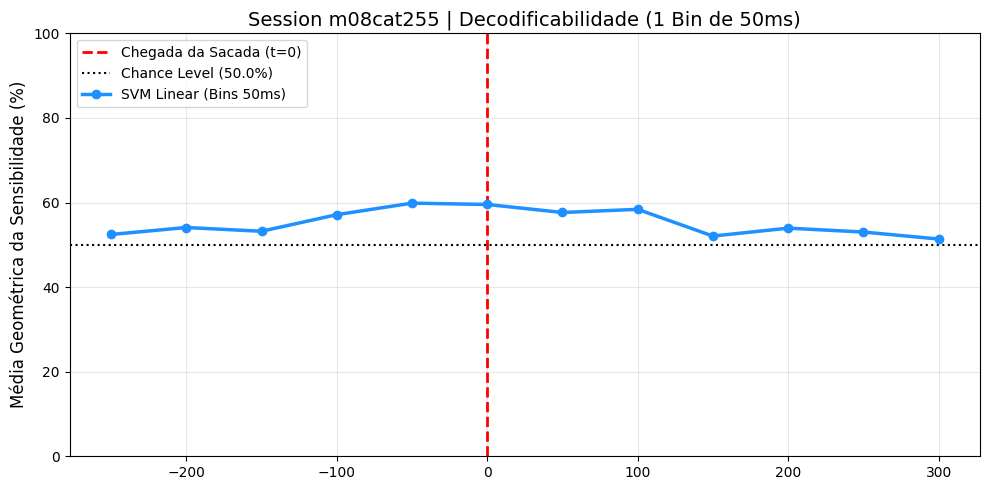

In [28]:
# metric = 'mean_acc'
# metric = 'mean_f1'
# metric = 'mean_mcc'
metric = 'mean_gm'

plt.figure(figsize=(10, 5))

# plt.axvspan(-200, 0, color='gray', alpha=0.15, label='Janela Preditiva Crítica (-200 a 0ms)')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Chegada da Sacada (t=0)')
plt.axhline(y=res_generic['chance_level'], color='black', linestyle=':', label=f"Chance Level ({res_generic['chance_level']:.1f}%)")

plt.plot(res_generic['window_ends'], res_generic[metric], color='dodgerblue', linewidth=2.5, marker='o', label='SVM Linear (Bins 50ms)')
# plt.fill_between(res_generic['window_ends'], res_generic[metric] - res_generic['sem_acc'], res_generic['mean_acc'] + res_generic['sem_acc'], color='dodgerblue', alpha=0.2)

plt.title(f'{STR_DETAILS} | Decodificabilidade (1 Bin de 50ms)', fontsize=14)
# plt.xlabel('Fim da Janela Temporal em Relação à Fixação (ms)', fontsize=12)
plt.ylabel('Acurácia (%)', fontsize=12)
plt.ylabel('Média Geométrica da Sensibilidade (%)', fontsize=12)
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

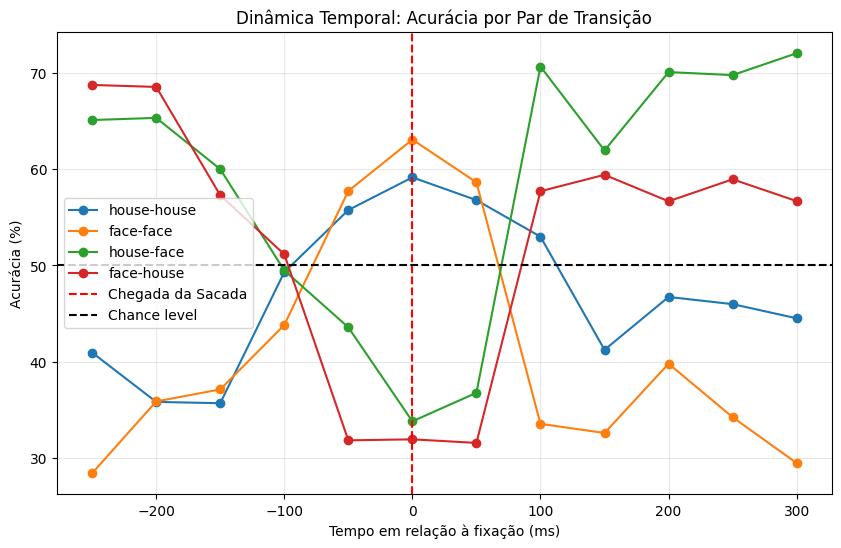

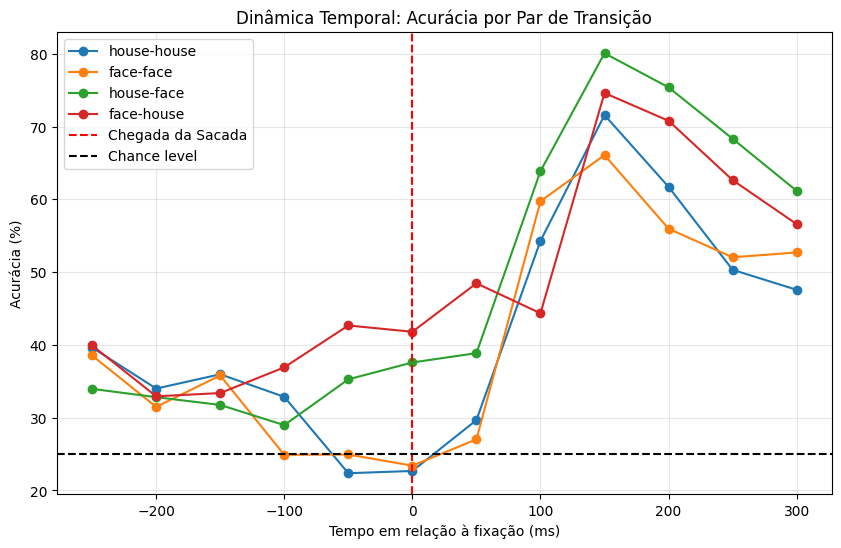

In [51]:

# pares_para_plotar = ['house-house','face-face','hand-hand','flower-flower', 'house-face','face-house']
pares_para_plotar = ['house-house','face-face', 'house-face','face-house']
# pares_para_plotar = res_generic['mean_acc_transition'].keys()
tempos = res_generic['window_ends']



plt.figure(figsize=(10,6))

for par in pares_para_plotar:
    # if par in res_generic['mean_acc_transition']:
    acc_temporal = res_generic['mean_acc_transition'][par]
    plt.plot(tempos, acc_temporal, marker='o', label=par)

plt.axvline(x=0, color='red', linestyle='--', label='Chegada da Sacada')
plt.axhline(y=50, color='black', linestyle='--', label='Chance level')
plt.ylabel('Acurácia (%)')
plt.xlabel('Tempo em relação à fixação (ms)')
plt.legend()
plt.title('Dinâmica Temporal: Acurácia por Par de Transição')
plt.grid(True, alpha=0.3)
plt.show()



# plt.figure(figsize=(20, 12))
plt.figure(figsize=(10,6))

for par in pares_para_plotar:
    # if par in res_category['mean_acc_transition']:
    acc_temporal = res_category['mean_acc_transition'][par]
    plt.plot(tempos, acc_temporal, marker='o', label=par)

plt.axvline(x=0, color='red', linestyle='--', label='Chegada da Sacada')
plt.axhline(y=25, color='black', linestyle='--', label='Chance level')
plt.ylabel('Acurácia (%)')
plt.xlabel('Tempo em relação à fixação (ms)')
plt.legend()
plt.title('Dinâmica Temporal: Acurácia por Par de Transição')
plt.grid(True, alpha=0.3)
plt.show()

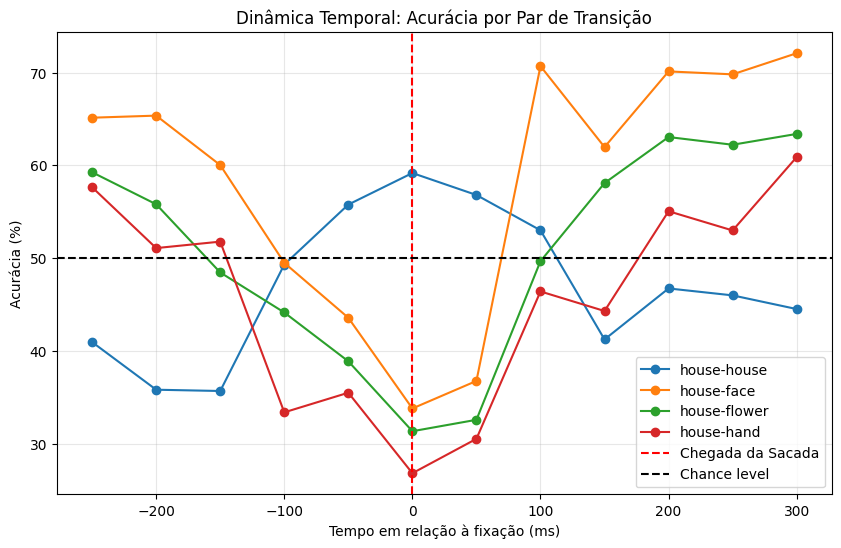

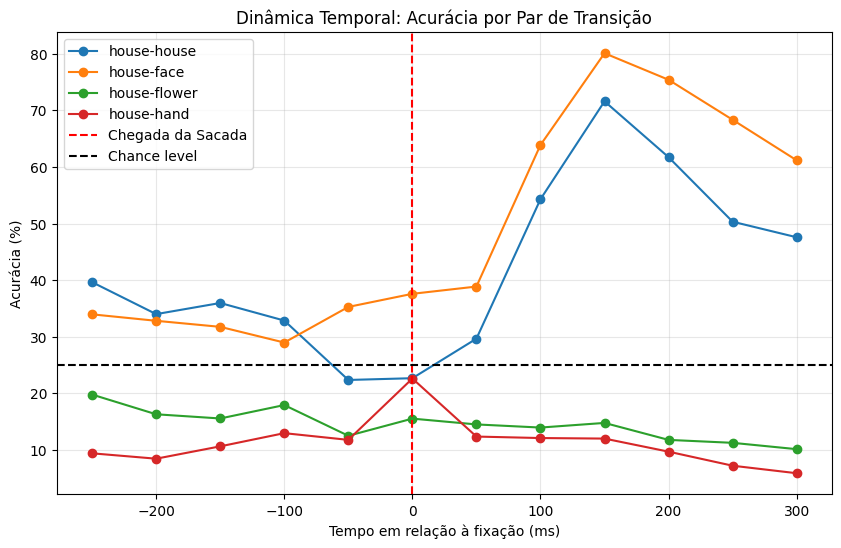

In [ ]:
import matplotlib.pyplot as plt

# pares_para_plotar = ['house-house','face-face','hand-hand','flower-flower', 'house-face','face-house']
pares_para_plotar = ['house-house','house-face','house-flower','house-hand']
# pares_para_plotar = res_generic['mean_acc_transition'].keys()
tempos = res_generic['window_ends']

# plt.figure(figsize=(20, 12))
plt.figure(figsize=(10,6))

for par in pares_para_plotar:
    # if par in res_generic['mean_acc_transition']:
    acc_temporal = res_generic['mean_acc_transition'][par]
    plt.plot(tempos, acc_temporal, marker='o', label=par)

plt.axvline(x=0, color='red', linestyle='--', label='Chegada da Sacada')
plt.axhline(y=50, color='black', linestyle='--', label='Chance level')
plt.ylabel('Acurácia (%)')
plt.xlabel('Tempo em relação à fixação (ms)')
plt.legend()
plt.title('Dinâmica Temporal: Acurácia por Par de Transição')
plt.grid(True, alpha=0.3)
plt.show()



# plt.figure(figsize=(20, 12))
plt.figure(figsize=(10,6))

for par in pares_para_plotar:
    # if par in res_category['mean_acc_transition']:
    acc_temporal = res_category['mean_acc_transition'][par]
    plt.plot(tempos, acc_temporal, marker='o', label=par)

plt.axvline(x=0, color='red', linestyle='--', label='Chegada da Sacada')
plt.axhline(y=25, color='black', linestyle='--', label='Chance level')
plt.ylabel('Acurácia (%)')
plt.xlabel('Tempo em relação à fixação (ms)')
plt.legend()
plt.title('Dinâmica Temporal: Acurácia por Par de Transição')
plt.grid(True, alpha=0.3)
plt.show()

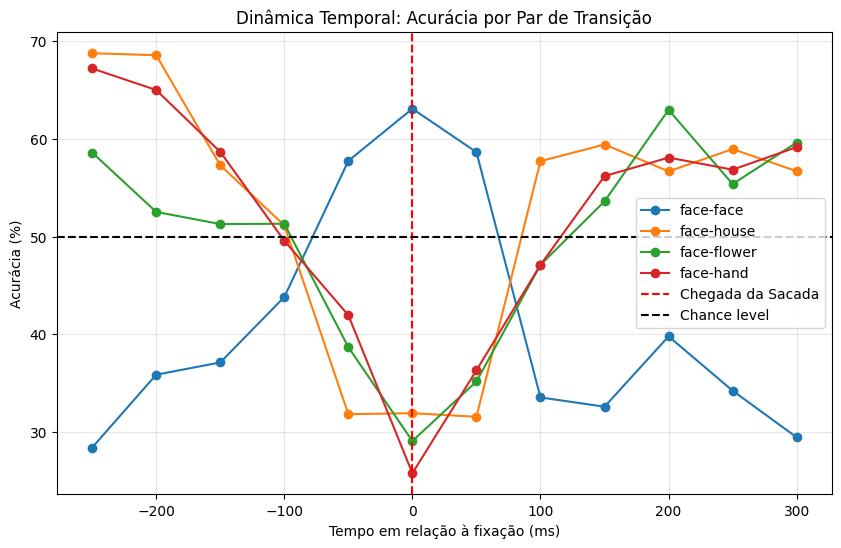

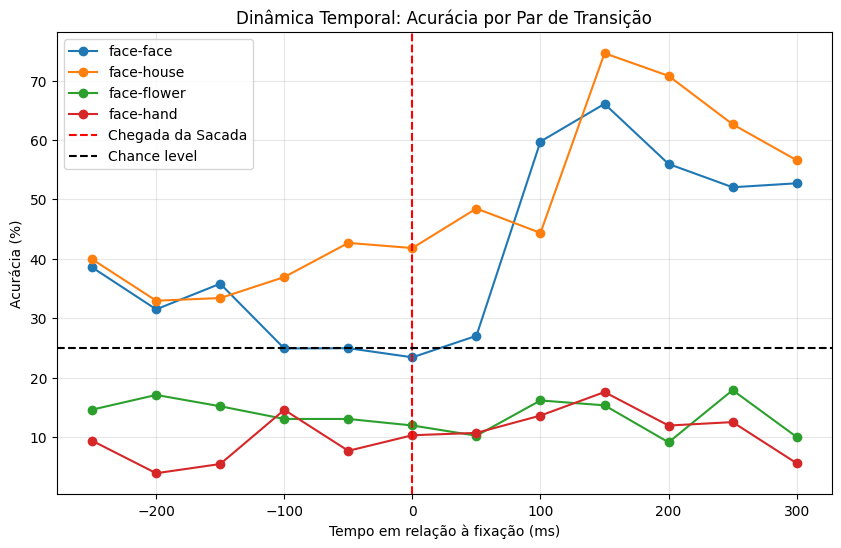

In [52]:

pares_para_plotar = ['face-face','face-house','face-flower','face-hand']
tempos = res_generic['window_ends']

plt.figure(figsize=(10,6))

for par in pares_para_plotar:
    # if par in res_generic['mean_acc_transition']:
    acc_temporal = res_generic['mean_acc_transition'][par]
    plt.plot(tempos, acc_temporal, marker='o', label=par)

plt.axvline(x=0, color='red', linestyle='--', label='Chegada da Sacada')
plt.axhline(y=50, color='black', linestyle='--', label='Chance level')
plt.ylabel('Acurácia (%)')
plt.xlabel('Tempo em relação à fixação (ms)')
plt.legend()
plt.title('Dinâmica Temporal: Acurácia por Par de Transição')
plt.grid(True, alpha=0.3)
plt.show()



# plt.figure(figsize=(20, 12))
plt.figure(figsize=(10,6))

for par in pares_para_plotar:
    # if par in res_category['mean_acc_transition']:
    acc_temporal = res_category['mean_acc_transition'][par]
    plt.plot(tempos, acc_temporal, marker='o', label=par)

plt.axvline(x=0, color='red', linestyle='--', label='Chegada da Sacada')
plt.axhline(y=25, color='black', linestyle='--', label='Chance level')
plt.ylabel('Acurácia (%)')
plt.xlabel('Tempo em relação à fixação (ms)')
plt.legend()
plt.title('Dinâmica Temporal: Acurácia por Par de Transição')
plt.grid(True, alpha=0.3)
plt.show()

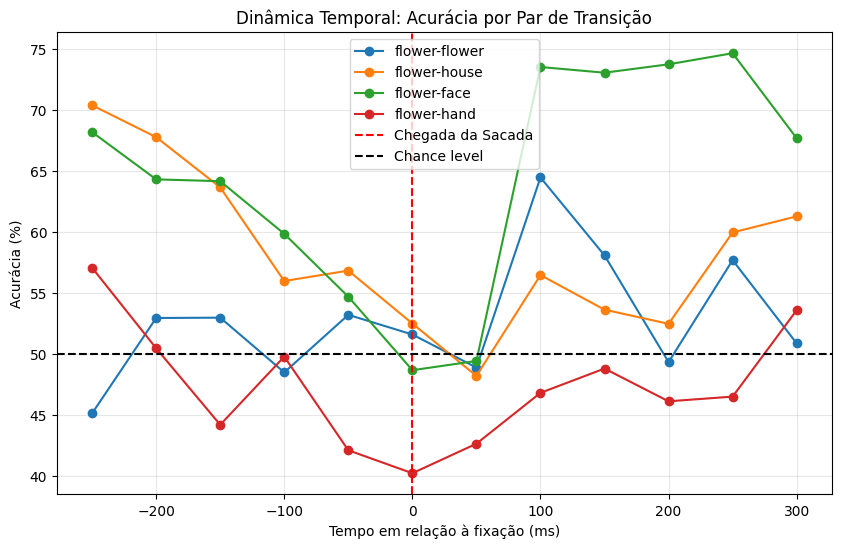

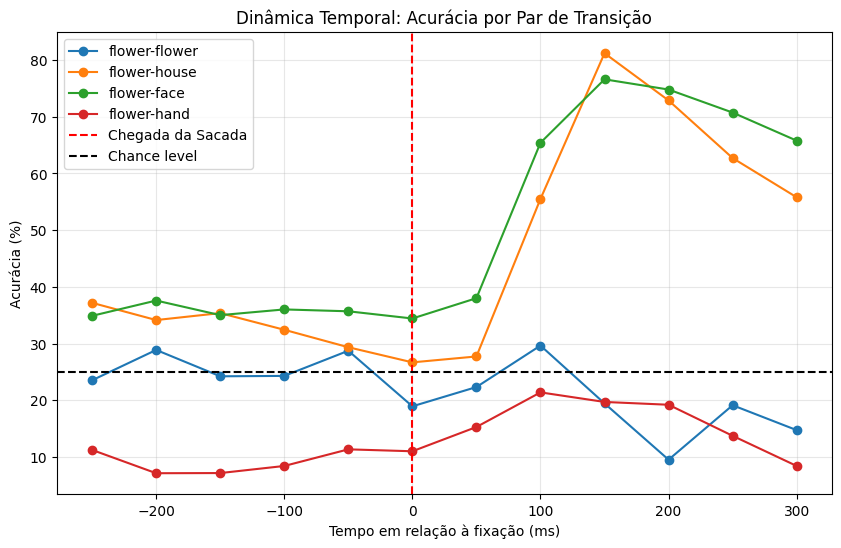

In [53]:

pares_para_plotar = ['flower-flower','flower-house','flower-face','flower-hand']
tempos = res_generic['window_ends']


plt.figure(figsize=(10,6))

for par in pares_para_plotar:
    # if par in res_generic['mean_acc_transition']:
    acc_temporal = res_generic['mean_acc_transition'][par]
    plt.plot(tempos, acc_temporal, marker='o', label=par)

plt.axvline(x=0, color='red', linestyle='--', label='Chegada da Sacada')
plt.axhline(y=50, color='black', linestyle='--', label='Chance level')
plt.ylabel('Acurácia (%)')
plt.xlabel('Tempo em relação à fixação (ms)')
plt.legend()
plt.title('Dinâmica Temporal: Acurácia por Par de Transição')
plt.grid(True, alpha=0.3)
plt.show()



# plt.figure(figsize=(20, 12))
plt.figure(figsize=(10,6))

for par in pares_para_plotar:
    # if par in res_category['mean_acc_transition']:
    acc_temporal = res_category['mean_acc_transition'][par]
    plt.plot(tempos, acc_temporal, marker='o', label=par)

plt.axvline(x=0, color='red', linestyle='--', label='Chegada da Sacada')
plt.axhline(y=25, color='black', linestyle='--', label='Chance level')
plt.ylabel('Acurácia (%)')
plt.xlabel('Tempo em relação à fixação (ms)')
plt.legend()
plt.title('Dinâmica Temporal: Acurácia por Par de Transição')
plt.grid(True, alpha=0.3)
plt.show()

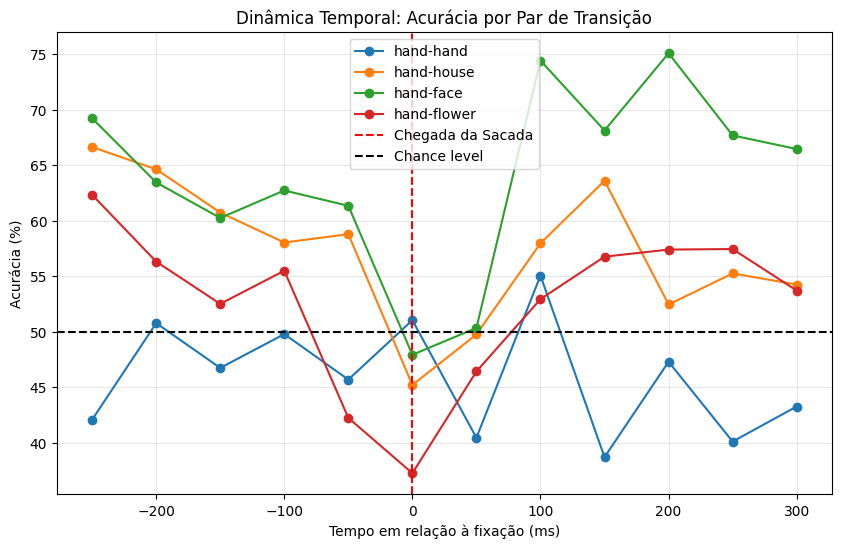

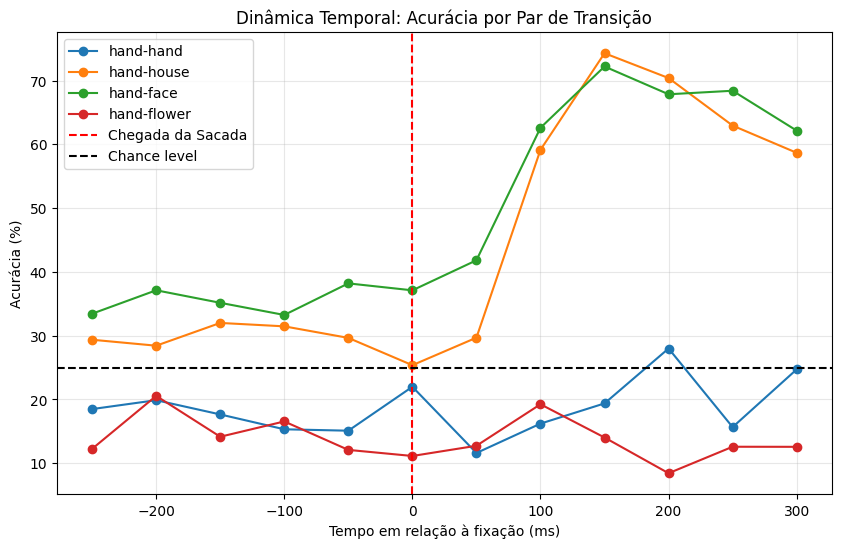

In [54]:

pares_para_plotar = ['hand-hand','hand-house','hand-face','hand-flower']
tempos = res_generic['window_ends']

plt.figure(figsize=(10,6))

for par in pares_para_plotar:
    # if par in res_generic['mean_acc_transition']:
    acc_temporal = res_generic['mean_acc_transition'][par]
    plt.plot(tempos, acc_temporal, marker='o', label=par)

plt.axvline(x=0, color='red', linestyle='--', label='Chegada da Sacada')
plt.axhline(y=50, color='black', linestyle='--', label='Chance level')
plt.ylabel('Acurácia (%)')
plt.xlabel('Tempo em relação à fixação (ms)')
plt.legend()
plt.title('Dinâmica Temporal: Acurácia por Par de Transição')
plt.grid(True, alpha=0.3)
plt.show()



# plt.figure(figsize=(20, 12))
plt.figure(figsize=(10,6))

for par in pares_para_plotar:
    # if par in res_category['mean_acc_transition']:
    acc_temporal = res_category['mean_acc_transition'][par]
    plt.plot(tempos, acc_temporal, marker='o', label=par)

plt.axvline(x=0, color='red', linestyle='--', label='Chegada da Sacada')
plt.axhline(y=25, color='black', linestyle='--', label='Chance level')
plt.ylabel('Acurácia (%)')
plt.xlabel('Tempo em relação à fixação (ms)')
plt.legend()
plt.title('Dinâmica Temporal: Acurácia por Par de Transição')
plt.grid(True, alpha=0.3)
plt.show()

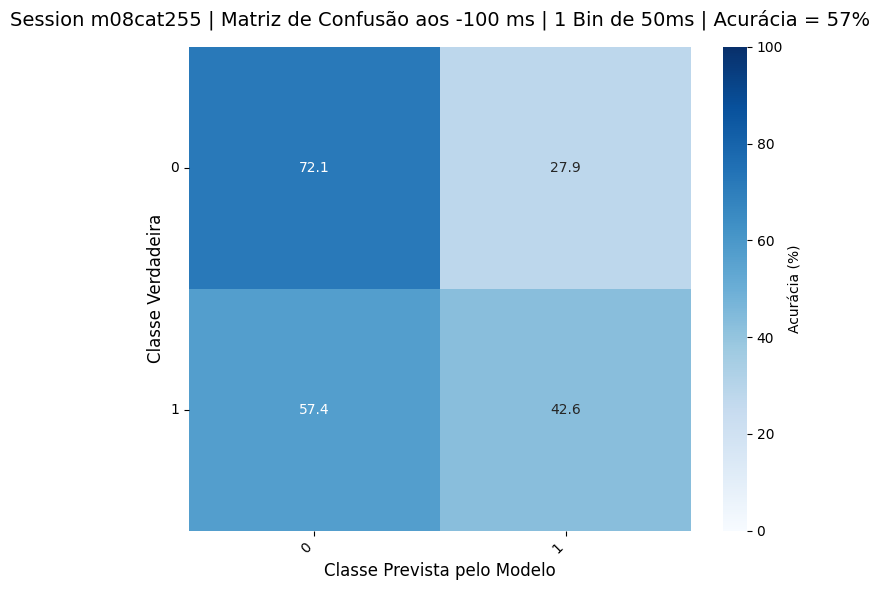

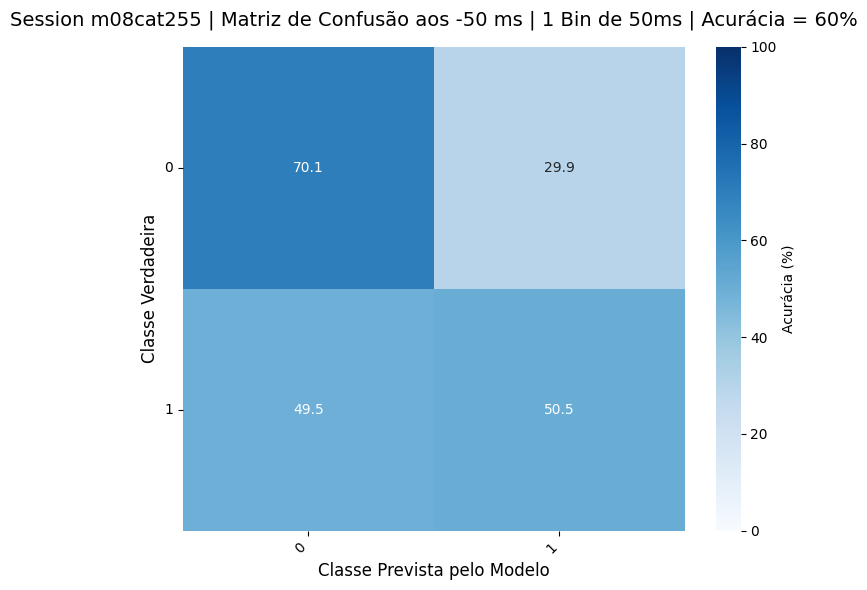

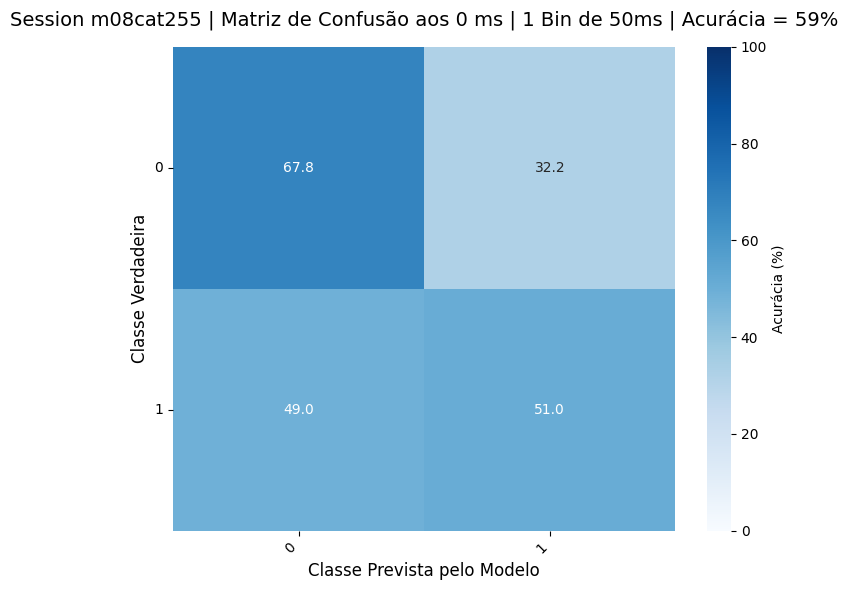

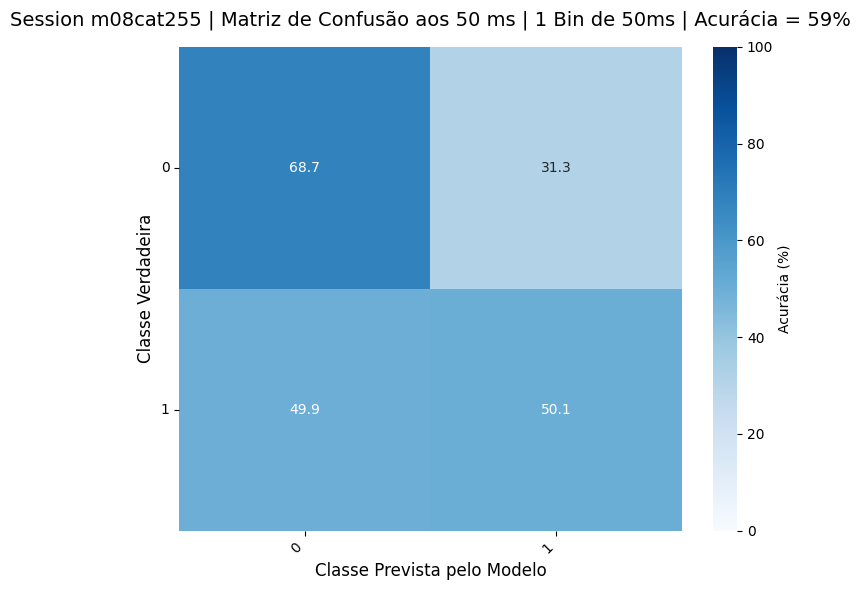

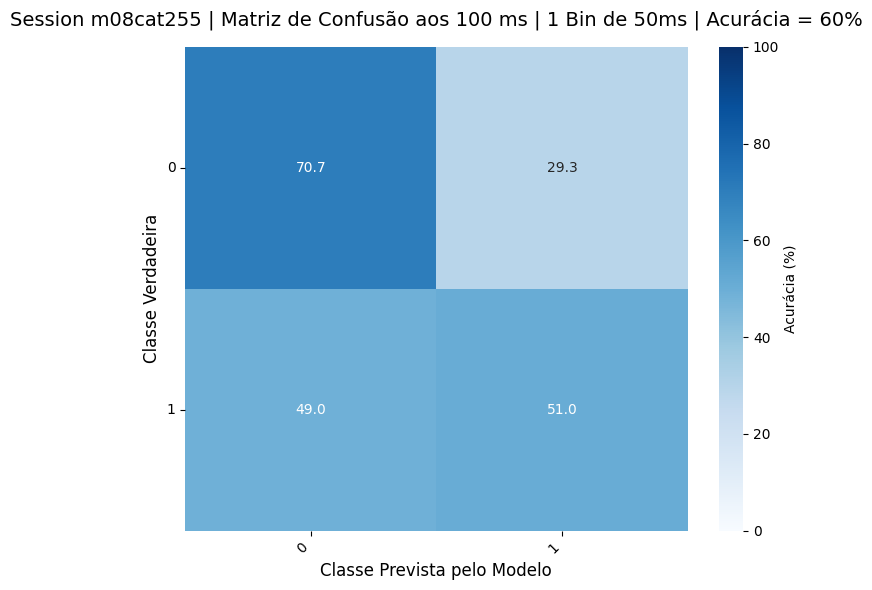

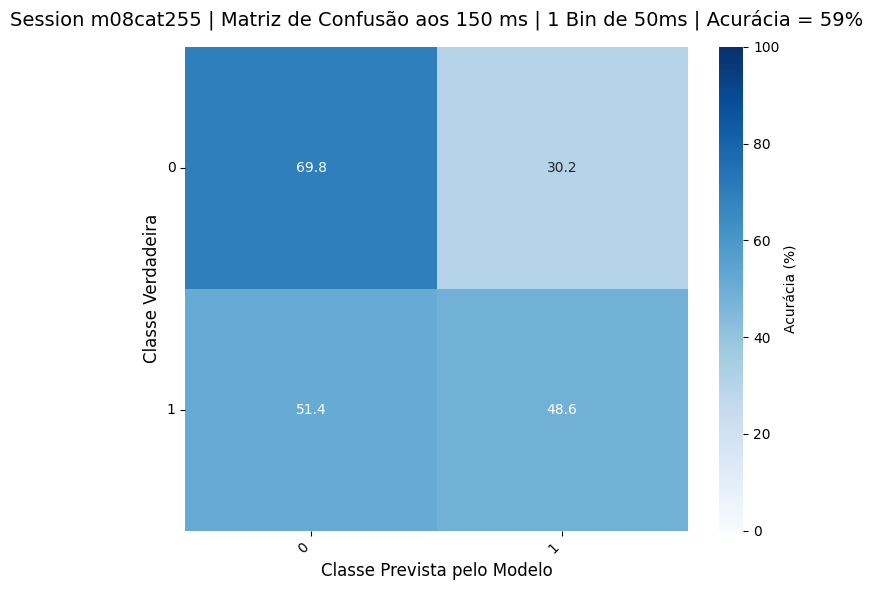

In [17]:
# plot_temporal_confusion_matrix(res_generic, target_time_ms=-200,str_bins='1 Bin de 50ms')
# plot_temporal_confusion_matrix(res_generic, target_time_ms=-150,str_bins='1 Bin de 50ms')
plot_temporal_confusion_matrix(res_generic, target_time_ms=-100,str_bins='1 Bin de 50ms')
plot_temporal_confusion_matrix(res_generic, target_time_ms=-50,str_bins='1 Bin de 50ms')
plot_temporal_confusion_matrix(res_generic, target_time_ms=0,str_bins='1 Bin de 50ms')
plot_temporal_confusion_matrix(res_generic, target_time_ms=50,str_bins='1 Bin de 50ms')
plot_temporal_confusion_matrix(res_generic, target_time_ms=100,str_bins='1 Bin de 50ms')
plot_temporal_confusion_matrix(res_generic, target_time_ms=150,str_bins='1 Bin de 50ms')

In [ ]:
# 1. Executa a função (ex: testando Bins isolados de 50ms)
res4bin = run_temporal_decoding(
    df_run_model=df_run_model, 
    num_bins=len(t_ends), 
    window_size_bins=4
    # window_size_bins=1
)


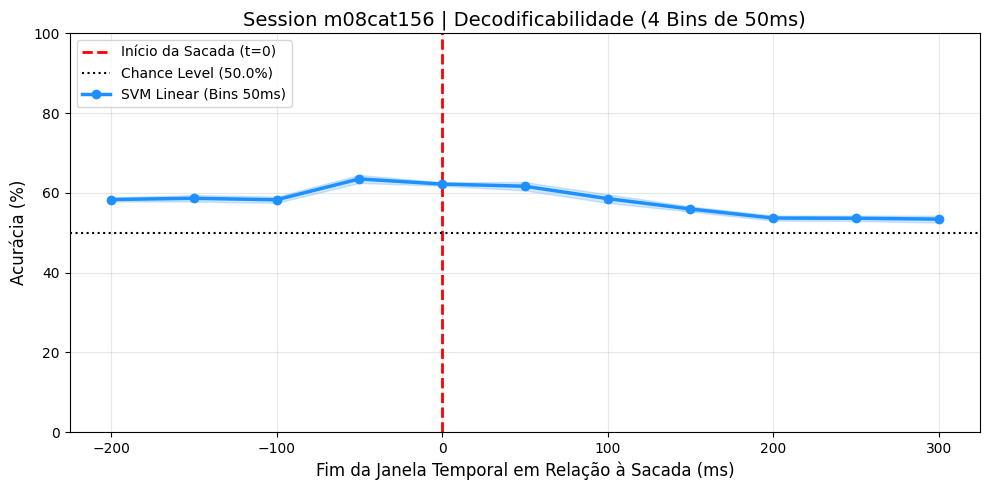

In [115]:
plt.figure(figsize=(10, 5))

# plt.axvspan(-200, 0, color='gray', alpha=0.15, label='Janela Preditiva Crítica (-200 a 0ms)')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Início da Sacada (t=0)')
plt.axhline(y=res0['chance_level'], color='black', linestyle=':', label=f"Chance Level ({res0['chance_level']:.1f}%)")

plt.plot(res0['window_ends'], res0['mean_acc'], color='dodgerblue', linewidth=2.5, marker='o', label='SVM Linear (Bins 50ms)')
plt.fill_between(res0['window_ends'], res0['mean_acc'] - res0['sem_acc'], res0['mean_acc'] + res0['sem_acc'], color='dodgerblue', alpha=0.2)

plt.title(f'{STR_DETAILS} | Decodificabilidade (4 Bins de 50ms)', fontsize=14)
plt.xlabel('Fim da Janela Temporal em Relação à Sacada (ms)', fontsize=12)
plt.ylabel('Acurácia (%)', fontsize=12)
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [116]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_temporal_confusion_matrix(result_decoding, target_time_ms,str_bins=''):
    """
    Plota a Matriz de Confusão para o instante de tempo (causal) mais próximo do solicitado.
    
    Parâmetros:
    -----------
    result_decoding : dict (retorno da função run_temporal_decoding)
    target_time_ms : int ou float (tempo em ms que você quer analisar, ex: 100)
    """
    
    # 1. Encontra o índice da janela temporal mais próxima do target_time_ms
    window_ends = result_decoding['window_ends']
    idx = np.argmin(np.abs(window_ends - target_time_ms))
    actual_time = window_ends[idx]
    
    # 2. Resgata a matriz e as classes exatas desse instante
    cm = result_decoding['mean_cms'][idx]
    classes = result_decoding['classes']
    
    # 3. Configura e plota o Heatmap
    plt.figure(figsize=(7, 6))
    
    # annot=True mostra os números, fmt='.1f' deixa 1 casa decimal, cmap é a paleta de cores
    sns.heatmap(cm, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=classes, yticklabels=classes,
                cbar_kws={'label': 'Acurácia (%)'},
                vmin=0, vmax=100)
    
    plt.title(f'{STR_DETAILS} | Matriz de Confusão aos {actual_time} ms | {str_bins} | Acurácia = {int(result_decoding["mean_acc"][list(result_decoding["window_ends"]).index(float(target_time_ms))])}%', fontsize=14, pad=15)
    # plt.title(f'{STR_DETAILS} | Matriz de Confusão (Fim da Janela: {actual_time} ms) (1 Bin de 50ms) | Acurácia = {int(result_decoding["mean_acc"][list(result_decoding["window_ends"]).index(float(target_time_ms))])}%', fontsize=14, pad=15)
    plt.ylabel('Classe Verdadeira', fontsize=12)
    plt.xlabel('Classe Prevista pelo Modelo', fontsize=12)
    
    # Rotaciona os rótulos para melhor leitura
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.show()



In [119]:
with open(f"pkl_temp_data\\temp_decoding_2409.pkl", "wb") as file:
    pickle.dump([res0, df_run_model], file)

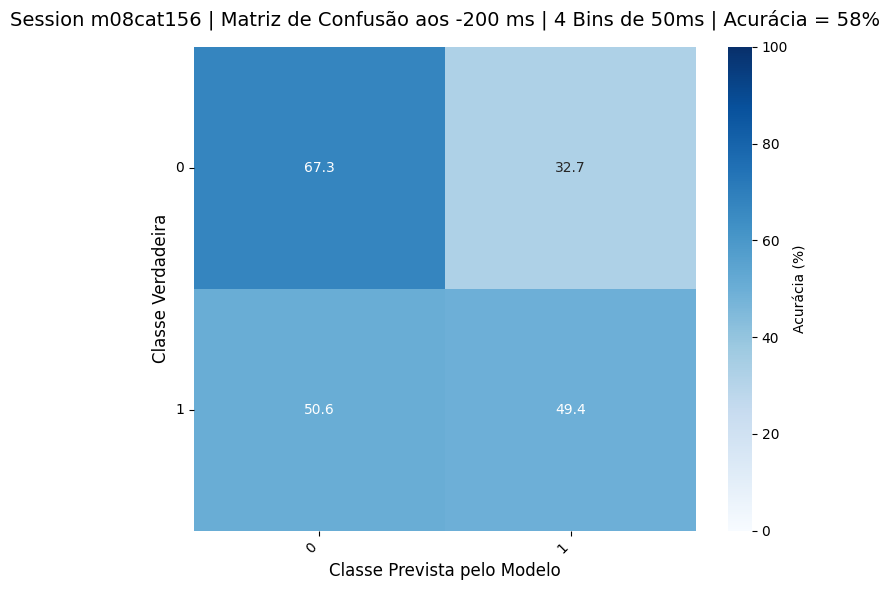

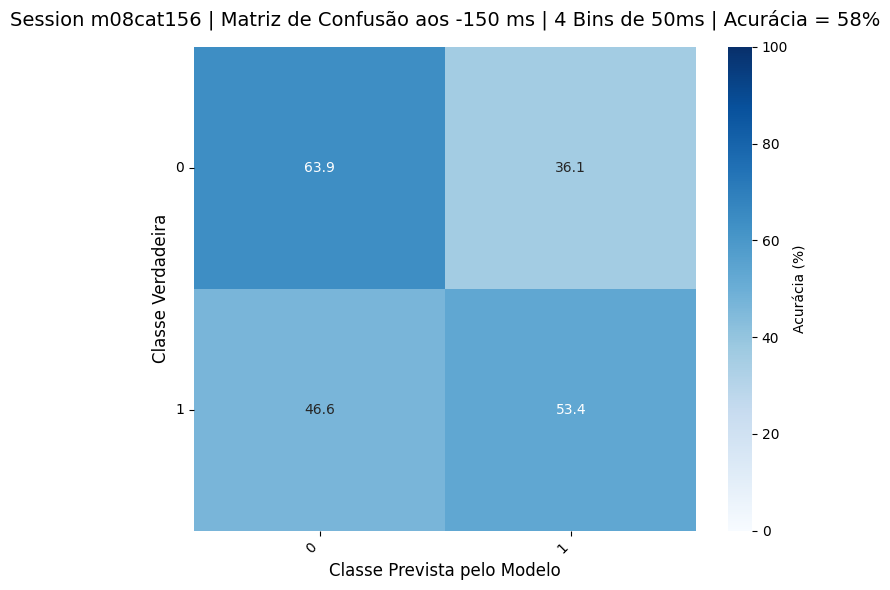

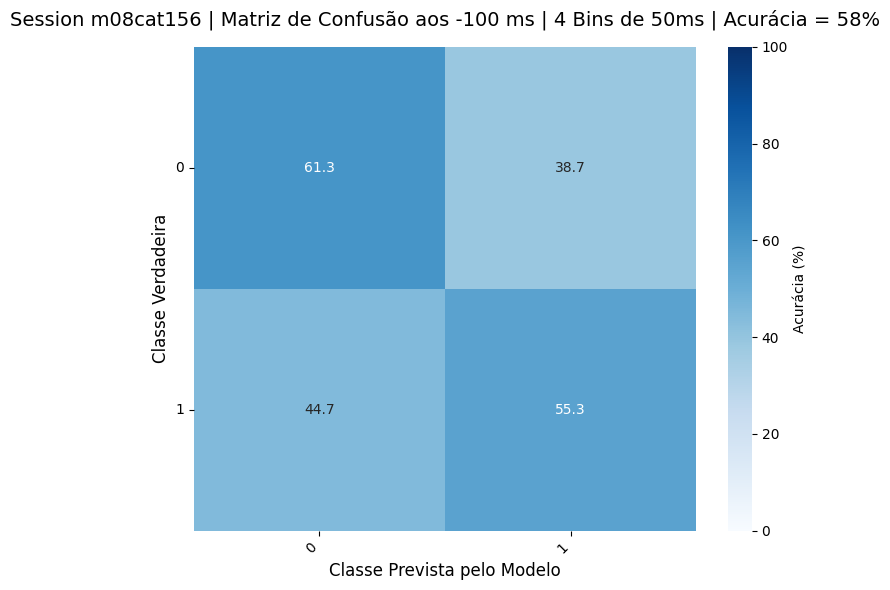

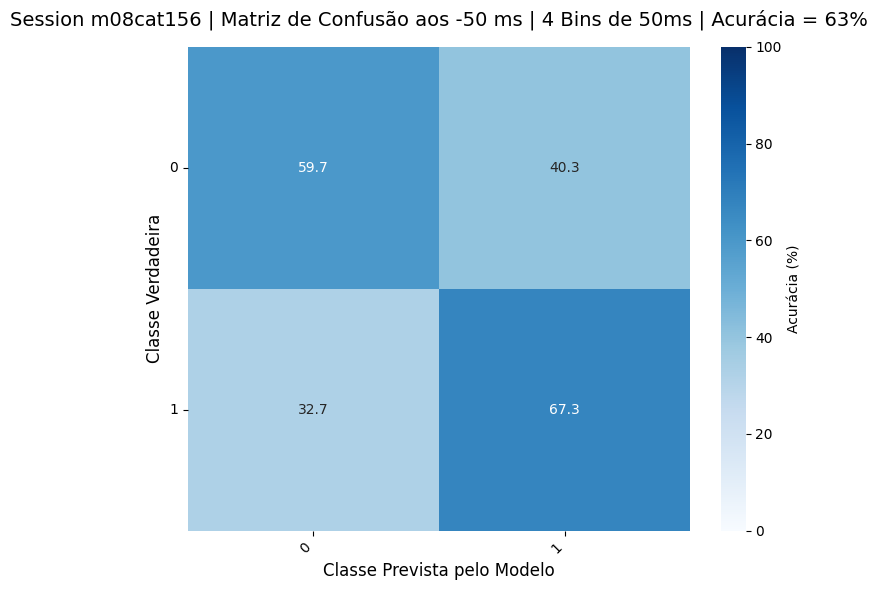

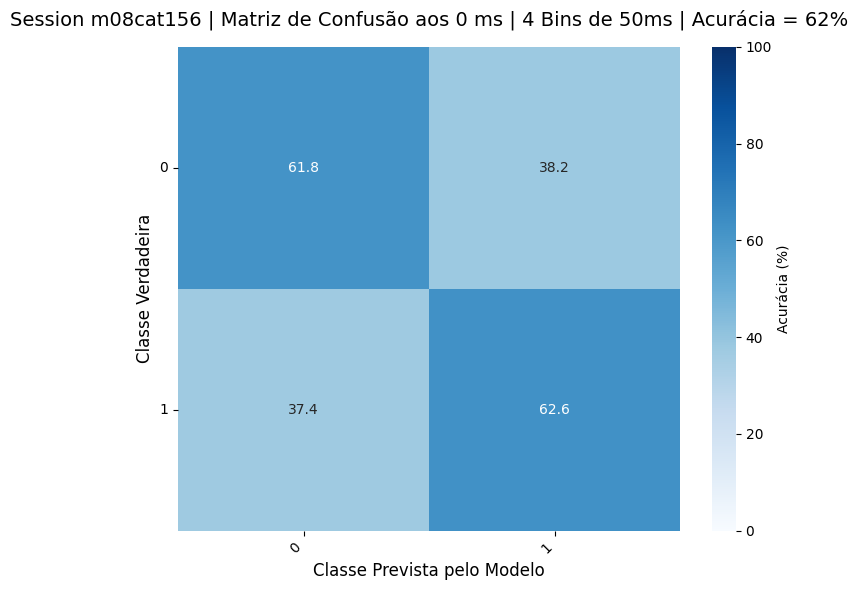

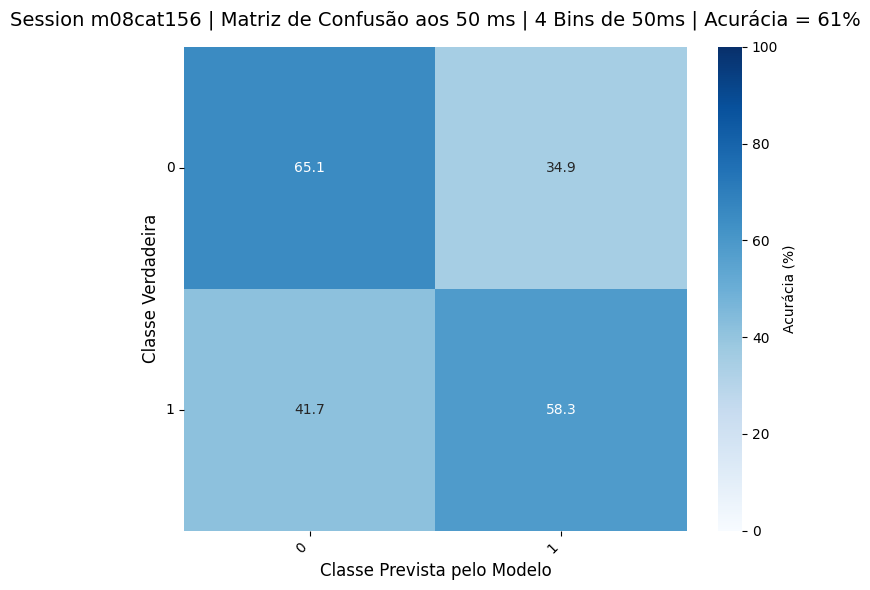

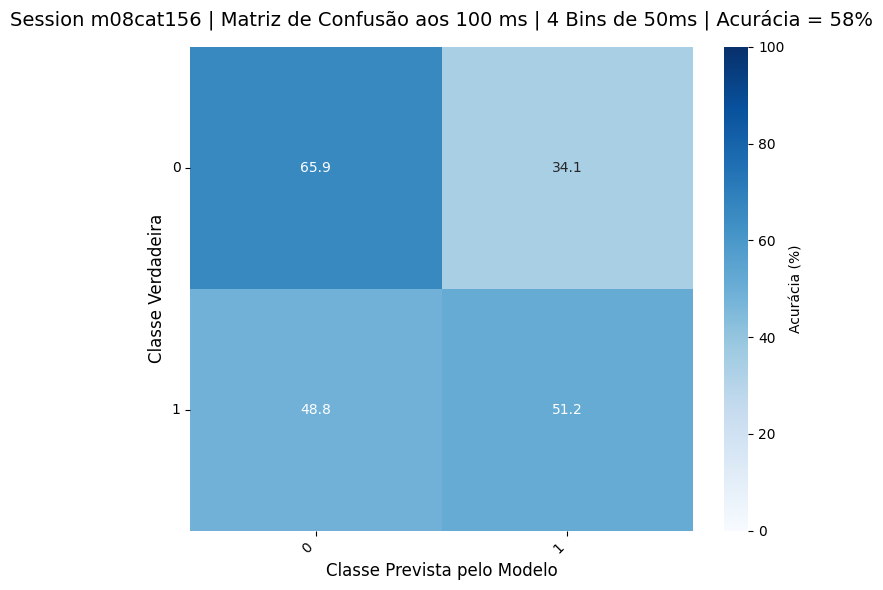

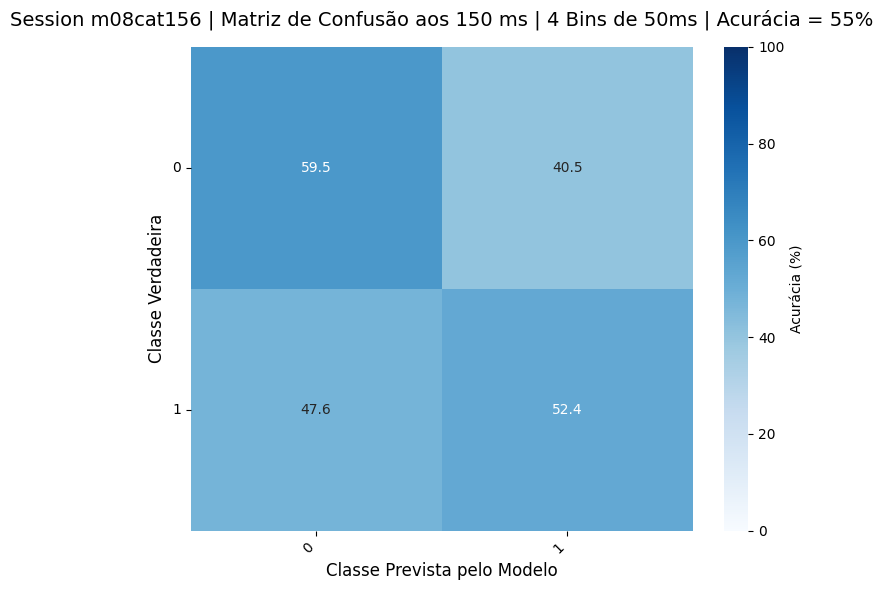

In [118]:
plot_temporal_confusion_matrix(res0, target_time_ms=-200,str_bins='4 Bins de 50ms')
plot_temporal_confusion_matrix(res0, target_time_ms=-150,str_bins='4 Bins de 50ms')
plot_temporal_confusion_matrix(res0, target_time_ms=-100,str_bins='4 Bins de 50ms')
plot_temporal_confusion_matrix(res0, target_time_ms=-50,str_bins='4 Bins de 50ms')
plot_temporal_confusion_matrix(res0, target_time_ms=0,str_bins='4 Bins de 50ms')
plot_temporal_confusion_matrix(res0, target_time_ms=50,str_bins='4 Bins de 50ms')
plot_temporal_confusion_matrix(res0, target_time_ms=100,str_bins='4 Bins de 50ms')
plot_temporal_confusion_matrix(res0, target_time_ms=150,str_bins='4 Bins de 50ms')

old

In [ ]:
# import numpy as np
# import pandas as pd
# from scipy.stats import loguniform
# from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
# from sklearn.svm import SVC
# from sklearn.metrics import balanced_accuracy_score
# from sklearn.metrics import confusion_matrix

# def zscore_per_neuron(X_train, X_test):
#     """
#     Calcula mu e sigma agregando TODOS os bins de cada neurônio apenas no TREINO,
#     e aplica essa padronização no Treino e no Teste.
#     """
#     X_train_z = X_train.copy()
#     X_test_z = X_test.copy()
    
#     neuron_ids = set([col.split('_Bin')[0] for col in X_train.columns])
    
#     for nid in neuron_ids:
#         cols_neuron = [col for col in X_train.columns if col.startswith(f"{nid}_Bin")]
#         train_values = X_train[cols_neuron].values.flatten()
        
#         mu = np.mean(train_values)
#         sigma = np.std(train_values)
        
#         if sigma == 0:
#             sigma = 1e-8
            
#         X_train_z[cols_neuron] = (X_train[cols_neuron] - mu) / sigma
#         X_test_z[cols_neuron] = (X_test[cols_neuron] - mu) / sigma
        
#     return X_train_z, X_test_z


# def run_temporal_decoding(df_run_model, num_bins, window_size_bins, num_folds=5, verbose=True):
#     """
#     Executa Nested Cross-Validation com SVM Linear e Moving Windows.
    
#     Parâmetros:
#     -----------
#     df_run_model : pd.DataFrame
#         DataFrame contendo a coluna target 'Y' e as colunas de spikes 'neuronio_BinX'.
#     num_bins : int
#         Número total de bins no dataset (ex: 14).
#     window_size_bins : int
#         Tamanho da janela deslizante em quantidade de bins (ex: 4 para 200ms, 1 para 50ms).
#     num_folds : int (default=5)
#         Quantidade de folds para o StratifiedKFold externo.
#     verbose : bool (default=True)
#         Se True, imprime o progresso do treinamento.
        
#     Retorna:
#     --------
#     results : dict
#         Dicionário contendo:
#         - 'mean_acc': Acurácia média por janela (%)
#         - 'sem_acc': Erro padrão da média (%)
#         - 'window_centers': Array com os tempos centrais das janelas (ms)
#         - 'window_ends': Array com os tempos de término (causais) das janelas (ms)
#         - 'chance_level': Nível do acaso teórico baseado no número de classes (%)
#         - 'fold_accuracies': Matriz bruta de acurácias (num_folds x num_windows) (%)
#     """
#     num_windows = num_bins - window_size_bins + 1
    
#     # Mapeamento do tempo das janelas (Assumindo bins de 50ms começando em -400ms)
#     window_centers = []
#     window_ends = []
#     for w in range(num_windows):
#         win_start_time = -400 + (w * 50)
#         win_end_time = win_start_time + (window_size_bins * 50)
#         window_centers.append((win_start_time + win_end_time) / 2.0)
#         window_ends.append(win_end_time)

#     X = df_run_model.drop(columns=['Y'])
#     y = df_run_model['Y']
    
#     # Nível do acaso com base no número de classes únicas
#     num_classes = len(np.unique(y))
#     chance_level = (1.0 / num_classes) * 100

#     outer_cv = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)
#     fold_accuracies = np.zeros((num_folds, num_windows))

#     if verbose:
#         print(f"Iniciando Decoding Pipeline ({num_folds} folds, {num_windows} janelas temporais)...")

#     classes = np.unique(y)
#     fold_cms = np.zeros((num_folds, num_windows, num_classes, num_classes))
#     for fold_idx, (train_idx, test_idx) in enumerate(outer_cv.split(X, y)):
#         if verbose:
#             print(f"--- Processando Fold {fold_idx + 1}/{num_folds} ---{pd.Timestamp.now()}")
            
#         X_train_raw, X_test_raw = X.iloc[train_idx], X.iloc[test_idx]
#         y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
#         # 1. Padronização Causal
#         X_train_z, X_test_z = zscore_per_neuron(X_train_raw, X_test_raw)
        
#         # 2. Tuning Bayesiano no Pós-Sacádico (Bins 10 a 13)
#         post_saccade_cols = [col for col in X_train_z.columns 
#                              if any(col.endswith(f"_Bin{b}") for b in [9, 10, 11, 12])]
#                             #  if any(col.endswith(f"_Bin{b}") for b in [10, 11, 12, 13])]
#         X_train_post = X_train_z[post_saccade_cols]
        
#         param_dist = {'C': loguniform(1e-4, 1e2)}
#         inner_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
        
#         search = RandomizedSearchCV(
#             estimator=SVC(kernel='linear', class_weight='balanced'),
#             param_distributions=param_dist,
#             n_iter=15,
#             cv=inner_cv,
#             scoring='balanced_accuracy',
#             random_state=42,
#             n_jobs=-1
#         )
#         search.fit(X_train_post, y_train)
#         best_C = search.best_params_['C']
#         print(f'Hyperparam C={best_C}')
        
#         # 3. Treino e Avaliação nas Moving Windows
#         best_svm = SVC(kernel='linear', class_weight='balanced', C=best_C)
        
#         for w_idx in range(num_windows):
#             active_bins = [w_idx + 1 + b for b in range(window_size_bins)]
#             win_cols = [col for col in X_train_z.columns 
#                         if any(col.endswith(f"_Bin{b}") for b in active_bins)]
            
#             X_tr_win = X_train_z[win_cols]
#             X_te_win = X_test_z[win_cols]
            
#             best_svm.fit(X_tr_win, y_train)
#             preds = best_svm.predict(X_te_win)
#             cm = confusion_matrix(y_test, preds, labels=classes, normalize='true')
#             fold_cms[fold_idx, w_idx] = cm
#             acc = balanced_accuracy_score(y_test, preds)
            
#             fold_accuracies[fold_idx, w_idx] = acc

#     # Prepara métricas para retorno
#     mean_acc = np.mean(fold_accuracies, axis=0) * 100
#     mean_cms = np.mean(fold_cms, axis=0) * 100
#     sem_acc = (np.std(fold_accuracies, axis=0) / np.sqrt(num_folds)) * 100

#     return {
#         'mean_acc': mean_acc,
#         'sem_acc': sem_acc,
#         'window_centers': np.array(window_centers),
#         'window_ends': np.array(window_ends),
#         'chance_level': chance_level,
#         'fold_accuracies': fold_accuracies * 100,
#         'mean_cms': mean_cms,
#         'classes': classes
#     }